# Machine Learning Project: Identifying Underinsured Individuals in the U.S. for Targeted Insurance Outreach

**Course:** Applied Machine Learning (CINTO2401U.LA_E25)

**Group:** 9 (Georg Sulzer, Justus Leopold Krauss, Max Häfke, Vincent Paul Konrad Wallerich)

---

## 0. Project Overview

This project explores how machine learning can help a private insurer identify potentially underinsured individuals, specifically those covered exclusively by Medicaid, to support more effective targeted outreach strategies. Using U.S. Census PUMS data, we examine how different levels of information availability influence model performance and practical deployment potential.

### 0.1 Business Case

Our goal is to identify individuals in the US who may be underinsured and therefore likely to benefit from supplementary private insurance products. In this project, we define “underinsured” as individuals who rely **exclusively on Medicaid**, since Medicaid provides only limited coverage and may leave gaps that private insurance can fill.

From the perspective of a private insurer, the ability to predict which individuals fall into this group is highly valuable:  
1. **Targeted marketing becomes more efficient**, as outreach can be focused on people with a higher need for additional coverage.  
2. **Customer acquisition costs can be reduced**, which is especially important given constraints such as limited marketing budgets and no access to public insurance databases.

By predicting whether a person has only Medicaid coverage using features that are either publicly accessible, obtainable through data brokers, or already available to the insurer through existing customer relationships, the company can more precisely identify potential customers and substantially improve the effectiveness and efficiency of its advertising and outreach strategy.


### 0.2 Machine Learning Problem

The task in this project is formulated as a **binary classification problem**, where the objective is to predict whether an individual is insured **exclusively through Medicaid** or has any additional form of health insurance. To address this problem, we apply several classification models and evaluate their performance under different feature availability scenarios. These include a feature set based on information that can be obtained from data brokers or publicly accessible sources, as well as an enriched feature set that incorporates insurer-specific information available for existing customers (e.g. through cross-selling relationships).

The goal is to assess how accurately potentially underinsured individuals can be identified under varying levels of data availability and model complexity.


### 0.3 Data Set

For this project, we use the **2024 Public Use Microdata Sample (PUMS)** from the **U.S. Census Bureau’s American Community Survey (ACS)**. The PUMS dataset provides individual-level, anonymized microdata with detailed demographic, socioeconomic, employment, and health insurance information for millions of U.S. residents. 

Because the full national dataset contains roughly three million person-level records - making computation more demanding - we focus our analysis on the **New England states**. However, the methods and models developed here are fully applicable to any other PUMS region or the nationwide dataset.

### 0.4 Pipeline Overview

The Jupyter Notebook is structured as a sequential pipeline that can be executed from start to finish. All required input data is provided in the `data` directory, allowing the notebook to be run end-to-end without manual intervention. The pipeline consists of the following steps: (1) data loading and optional exploratory analyses for data understanding, (2) data cleaning and feature engineering, (3) model training, (4) model evaluation, and (5) fairness analysis.

*Note:* Running the complete notebook typically takes around 30 minutes on our machines, as model training and hyperparameter tuning are computationally intensive.

---

## 1. Data

Before preparing the data for model training, we explore the raw dataset to gain an understanding of its structure and features.

> *Section 1.1 covers the setup and data loading process. Sections 1.2–1.4 provide additional analyses for data understanding and intuition, including data quality checks, health insurance coverage combinations, and exploratory feature analysis. These sections are exploratory in nature and optional to run, and they do not affect the subsequent modelling pipeline.*

### 1.1 Setup and Data Loading

We import all required libraries, configure global settings, and define path dependencies for loading and processing the dataset.


In [1]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
import logging
from datetime import datetime
from pathlib import Path
from sklearn.feature_selection import VarianceThreshold
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_selection import mutual_info_classif
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix, average_precision_score
import joblib
from sklearn.metrics import RocCurveDisplay, ConfusionMatrixDisplay
import re
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
#from lightgbm import LGBMClassifier
from sklearn.neural_network import MLPClassifier
from imblearn.over_sampling import SMOTE
from sklearn.dummy import DummyClassifier
import time

# Configuration
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
logging.basicConfig(level=logging.INFO, format='%(message)s')
logger = logging.getLogger()

# Define Paths
DATA_DIR = '00 data/raw/'
RAW_FILES = [
    'connecticut.csv'
]

In [2]:
from fairlearn.metrics import (
    MetricFrame,
    true_positive_rate,
    false_positive_rate,
    selection_rate,
    equalized_odds_difference,
    demographic_parity_difference,
    demographic_parity_ratio
)
from fairlearn.postprocessing import ThresholdOptimizer

We then load the raw **ACS PUMS 2024** data for the New England states and combine the individual state files into a single dataframe, which forms the basis for all subsequent analyses.

In [3]:
# Load and concatenate raw data files
dfs = [
    pd.read_csv(os.path.join(DATA_DIR, file))
    for file in set(RAW_FILES)
    if os.path.exists(os.path.join(DATA_DIR, file))
]

df_raw = pd.concat(dfs, ignore_index=True)

print(f"All data loaded. Total rows: {len(df_raw):,}")

All data loaded. Total rows: 37,903


In [4]:
print(f"Data Shape: {df_raw.shape[0]:,} rows, {df_raw.shape[1]} columns")
display(df_raw.head(5))

Data Shape: 37,903 rows, 286 columns


,RT,SERIALNO,DIVISION,SPORDER,PUMA,REGION,STATE,ADJINC,PWGTP,AGEP,...,PWGTP71,PWGTP72,PWGTP73,PWGTP74,PWGTP75,PWGTP76,PWGTP77,PWGTP78,PWGTP79,PWGTP80
0,P,2024GQ0000164,1,1,20500,1,9,1015250,13,36,...,14,15,13,13,16,16,12,14,13,11
1,P,2024GQ0000190,1,1,20603,1,9,1015250,84,21,...,82,80,83,88,83,81,83,79,83,86
2,P,2024GQ0000304,1,1,20603,1,9,1015250,52,85,...,53,55,49,50,54,53,51,52,53,53
3,P,2024GQ0000319,1,1,20201,1,9,1015250,56,19,...,65,60,5,125,50,50,55,4,111,5
4,P,2024GQ0000366,1,1,20203,1,9,1015250,29,19,...,55,32,28,27,55,3,2,2,3,33


### 1.2 Data Quality Checks *(optional)*

We then assess data quality by (1) checking for duplicate records and (2) analyzing the presence of missing values across all features. This helps identify potential data issues and informs subsequent cleaning and imputation decisions.

In [5]:
# Check duplicates
dup_count = df_raw.duplicated(keep=False).sum()  # keep=False marks all duplicates as True
dup_pct = (dup_count / len(df_raw)) * 100
print(f"Duplicate Rows: {dup_count:,} ({dup_pct:.2f}% of dataset)")

Duplicate Rows: 0 (0.00% of dataset)


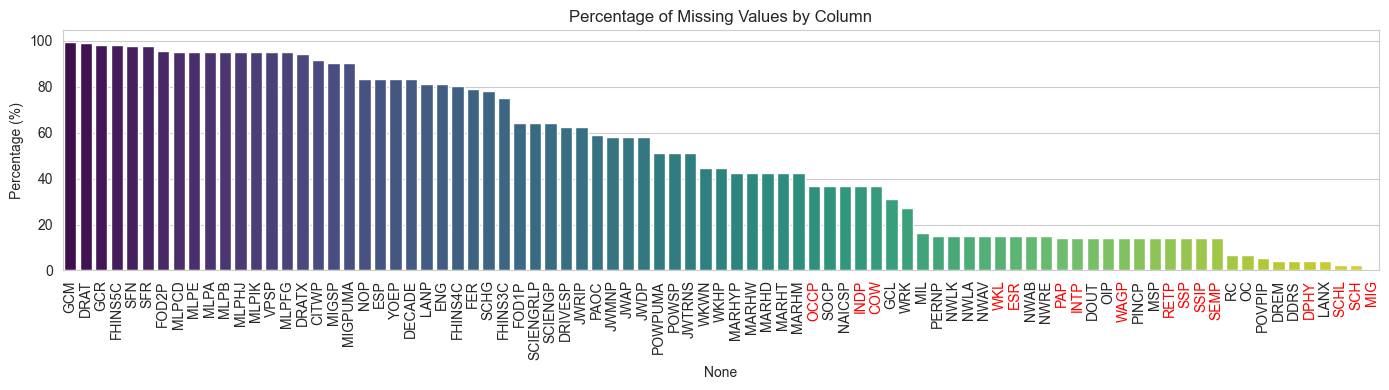

In [6]:
# Check missing values
missing = df_raw.isnull().sum()
missing = missing[missing > 0]

missing_pct = (missing / len(df_raw)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Percentage': missing_pct})

# Sort by percentage descending
missing_df = missing_df.sort_values('Percentage', ascending=False)

# Plot
plt.figure(figsize=(14, 4))
ax = sns.barplot(
    x=missing_df.index,
    y=missing_df['Percentage'],
    palette='viridis'
)

plt.title('Percentage of Missing Values by Column')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=90)

# Highlight selected features from 2.1 Feature Selection
keep_cols = ['WAGP', 'SEMP', 'INTP', 'RETP', 'SSP', 'SSIP', 'PAP', 'ESR', 'COW', 'WKL', 'OCCP', 'INDP', 'AGEP', 'SEX', 'MAR', 'MIG', 'NATIVITY', 'RAC1P', 'HISP','SCHL', 'SCH', 'DIS', 'DEAR', 'DEYE', 'DPHY', 'STATE', 'PUMA']

for label in ax.get_xticklabels():
    if label.get_text() in keep_cols:
        label.set_color('red')

plt.tight_layout()
plt.show()

*Note:* Features highlighted in **red** indicate variables retained for modelling during the feature selection step (Section 2.1). While the dataset contains a substantial number of missing values overall, the selected features have manageable levels of missingness, which are addressed in the data cleaning process (Section 2.2).

### 1.3 Health Insurance Combinations & Class Imbalances *(optional)*

The PUMS dataset contains seven binary health insurance indicators (`HINS1`–`HINS7`) representing different types of coverage, which can occur in *various combinations* for each individual. We analyze the most common combinations of these indicators (1) to understand how insurance coverage is structured in the data and (2) to gain an initial understanding of potential class imbalances relevant for the subsequent modelling task.

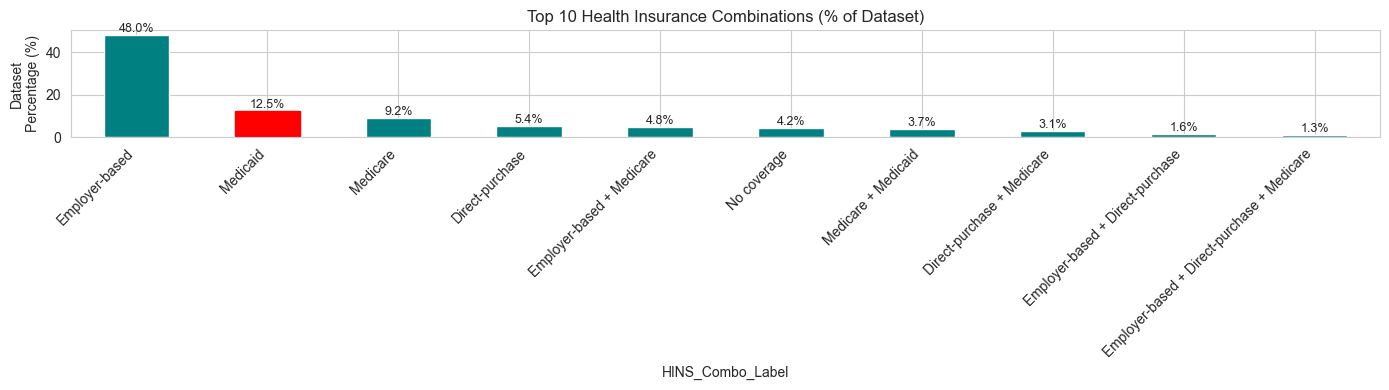

In [7]:
# Define HINS labels
hins_labels = {
    'HINS1': 'Employer-based',
    'HINS2': 'Direct-purchase',
    'HINS3': 'Medicare',
    'HINS4': 'Medicaid',
    'HINS5': 'Tricare/VA',
    'HINS6': 'Other public',
    'HINS7': 'No coverage'
}

# Identify health insurance indicator columns
hins_cols = sorted([c for c in df_raw.columns if c.startswith('HINS') and len(c) == 5])

# Create a readable combination label per individual
def map_hins_combo(row):
    combo_parts = []
    for col in hins_cols:
        if row[col] == 1:
            combo_parts.append(hins_labels.get(col, col))
    return ' + '.join(combo_parts) if combo_parts else 'No coverage'

df_raw['HINS_Combo_Label'] = df_raw.apply(map_hins_combo, axis=1)

# Get most frequent combinations
top_combos = (
    df_raw['HINS_Combo_Label']
    .value_counts(normalize=True)
    .head(10) * 100
)

# Plot top combinations
plt.figure(figsize=(14, 4))
ax = top_combos.plot(kind='bar', color='teal')

# Highlight Medicaid-only bar in red
for i, label in enumerate(top_combos.index):
    if label == 'Medicaid':
        ax.patches[i].set_color('red')

# Add percentage labels on bars
for p in ax.patches:
    height = p.get_height()
    ax.annotate(
        f'{height:.1f}%',
        (p.get_x() + p.get_width() / 2, height),
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.title('Top 10 Health Insurance Combinations (% of Dataset)')
plt.ylabel('Dataset\nPercentage (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

*Note:* Each bar represents a distinct and mutually exclusive insurance coverage group. This distribution helps us identify the proportion of individuals covered *exclusively* by Medicaid and understand potential class imbalances in the data.

### 1.4 Exploratory Feature Analysis *(optional)*

In this section, we analyze relationships between individual features and the target variable `only_medicaid`, which indicates whether a person is covered *exclusively* by Medicaid (based on the insurance indicator combinations discussed in Section 1.3). Using correlation analysis and mutual information, we gain insights into feature relevance that help guide feature selection decisions later in the modelling pipeline.

In [8]:
# Create target variable: only_medicaid (only for this analysis, later again defined in Section 2.3)
insurance_cols = ['HINS1', 'HINS2', 'HINS3', 'HINS5', 'HINS6', 'HINS7']

df_raw['only_medicaid'] = np.where(
    (df_raw['HINS4'] == 1) & df_raw[insurance_cols].eq(2).all(axis=1),
    1,
    0
)

#### 1.4.1 Correlation

We compute the absolute correlation between numeric features and the target variable `only_medicaid` to identify features with strong linear relationships to Medicaid-only coverage.

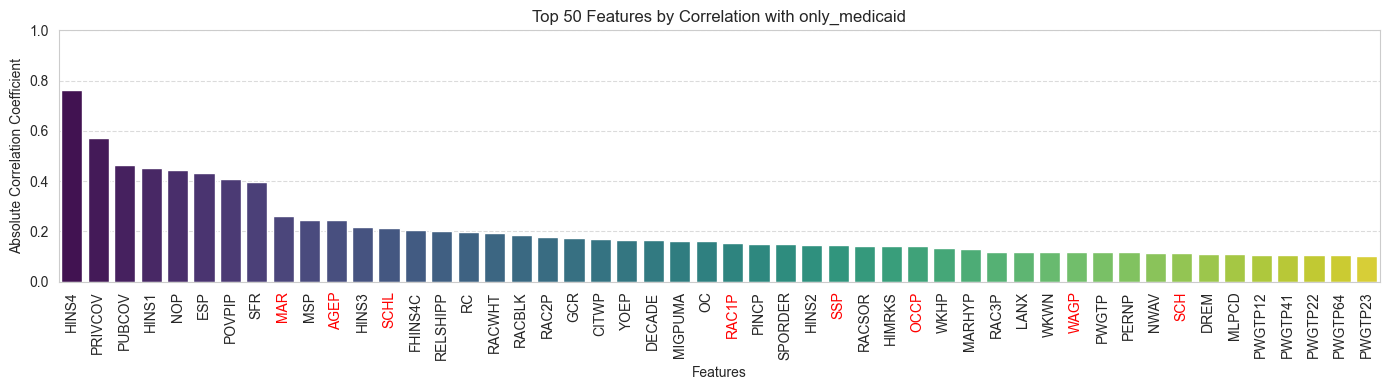

In [9]:
# Define numeric columns
numeric_cols = df_raw.select_dtypes(include=[np.number]).columns

# Calculate correlation of all numeric features with only_medicaid
corr_with_target = (
    df_raw[numeric_cols]
    .corrwith(df_raw['only_medicaid'])
    .abs()
    .sort_values(ascending=False)
)

# Remove target itself from the results
corr_with_target = corr_with_target.drop('only_medicaid', errors='ignore')

# Convert to DataFrame
corr_df = pd.DataFrame(corr_with_target, columns=['Correlation Coefficient'])

# Get top 50 features
top_50 = corr_df.head(50)

# Plot
plt.figure(figsize=(14, 4))
ax = sns.barplot(
    x=top_50.index,
    y=top_50['Correlation Coefficient'],
    palette='viridis'
)

plt.title('Top 50 Features by Correlation with only_medicaid')
plt.xlabel('Features')
plt.ylabel('Absolute Correlation Coefficient')
plt.ylim(0, 1)
plt.xticks(rotation=90)
plt.grid(axis='y', linestyle='--', alpha=0.7)

keep_set = set(keep_cols)
for label in ax.get_xticklabels():
    if label.get_text().strip() in keep_set:
        label.set_color('red')

plt.tight_layout()
plt.show()


*Note:* Some features show strong correlation with the target variable but are not included in the final modelling feature sets. Feature selection is guided by substantive and practical considerations and is discussed in more detail in Section 2.1 (Feature Selection).

#### 1.4.2 Mutual Information

We calculate mutual information scores between features and `only_medicaid` to capture non-linear dependencies and rank features by their overall predictive relevance.

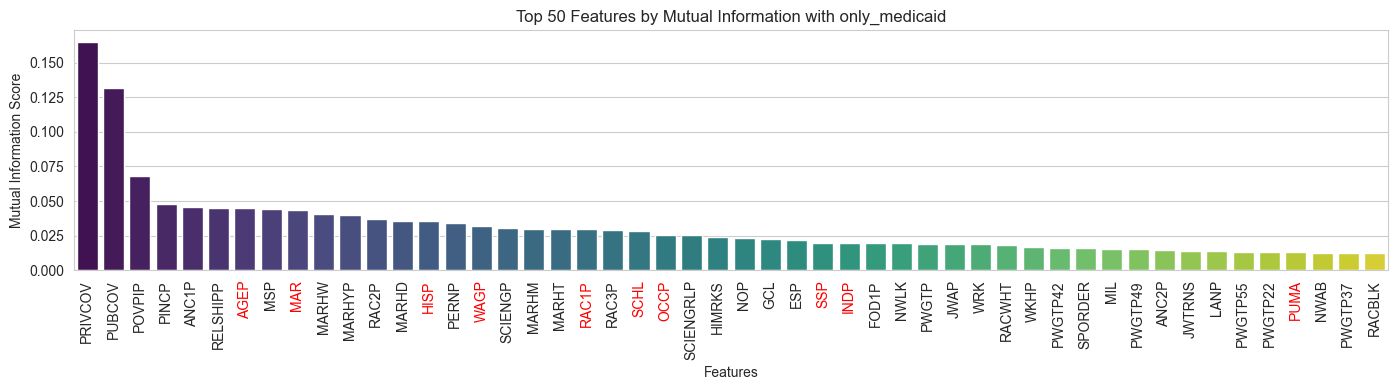

In [10]:
# Use a sample for speed
sample_df = df_raw.sample(min(5000, len(df_raw)), random_state=42).fillna(0)

# Define X and y for mutual information
drop_cols = ['only_medicaid'] + [c for c in sample_df.columns if c.startswith('HINS')]
X_mi = sample_df.select_dtypes(include=[np.number]).drop(columns=drop_cols, errors='ignore')
y_mi = sample_df['only_medicaid']

# Mutual information
mi = mutual_info_classif(X_mi, y_mi, random_state=42)
mi_series = pd.Series(mi, index=X_mi.columns).sort_values(ascending=False)

# Plot TOP 50 Mutual Information scores
plt.figure(figsize=(14, 4))
top_50_mi = mi_series.head(50)

ax = sns.barplot(x=top_50_mi.index, y=top_50_mi.values, palette='viridis')

plt.title('Top 50 Features by Mutual Information with only_medicaid')
plt.xlabel('Features')
plt.ylabel('Mutual Information Score')
plt.xticks(rotation=90)

# Highlight selected features
keep_set = set(keep_cols)
for label in ax.get_xticklabels():
    if label.get_text().strip() in keep_set:
        label.set_color('red')

plt.tight_layout()
plt.show()

*Note:* Some features show strong mutual information with the target variable but are not included in the final modelling feature sets. Feature selection is guided by substantive and practical considerations and is discussed in more detail in Section 2.1 (Feature Selection).

---

## 2. Data Cleaning and Feature Engineering

After exploring the initial dataset, we transform the raw data into model-ready feature sets through a structured data cleaning and feature engineering process.

> *Section 2.1 reduces the dataset to the features relevant for modelling, while Section 2.2 focuses on data cleaning tasks such as handling missing values and ensuring data consistency. Section 2.3 constructs the target variable and engineers additional features to create a fully processed modelling dataframe. Finally, Section 2.4 generates multiple feature subsets for comparison: a **Realistic** set containing only publicly accessible or data-broker–derived information, and a **Cross-Selling** set enriched with additional attributes an insurer would already have for existing customers (e.g. through cross-selling). For both feature sets, PCA-reduced variants are also created to assess the impact of dimensionality reduction on model performance.* 

### 2.1 Feature Selection

First, we filter the dataset to retain only the features that are relevant for our analysis, grouped by domain. This step reduces dimensionality and focuses the models on the most informative variables. The features in the target-related group are later used to engineer the target variable (`only_medicaid`) and are subsequently removed from the feature set to avoid data leakage during model training.

**Kept Features:**  
*(A detailed description of all variables and their definitions is provided in the Appendix.)*

- **Group 1 (Income & Affordability):** `WAGP`, `SEMP`, `INTP`, `RETP`, `SSP`, `SSIP`, `PAP`
- **Group 2 (Employment Quality):** `ESR`, `COW`, `WKL`, `OCCP`, `INDP`
- **Group 3 (Demographics):** `AGEP`, `SEX`, `MAR`, `MIG`, `NATIVITY`, `RAC1P`, `HISP`
- **Group 4 (Education):** `SCHL`, `SCH`
- **Group 5 (Health & Disability):** `DIS`, `DEAR`, `DEYE`, `DPHY`
- **Group 6 (Geography):** `STATE`, `PUMA`
- **Target Group (Health Insurance Indicators):** `HINS4`, `HINS1`, `HINS2`, `HINS3`, `HINS5`, `HINS6`, `HINS7`


In [11]:
keep_cols = [
    # Income & Affordability
    'WAGP', 'SEMP', 'INTP', 'RETP', 'SSP', 'SSIP', 'PAP',
    # Employment Quality
    'ESR', 'COW', 'WKL', 'OCCP', 'INDP',
    # Demographics
    'AGEP', 'SEX', 'MAR', 'MIG', 'NATIVITY', 'RAC1P', 'HISP',
    # Education
    'SCHL', 'SCH',
    # Health & Disability
    'DIS', 'DEAR', 'DEYE', 'DPHY',
    # Geography
    'STATE', 'PUMA',
    # Health Insurance Indicators
    'HINS4', 'HINS1', 'HINS2', 'HINS3', 'HINS5', 'HINS6', 'HINS7',
]

existing_cols = [c for c in keep_cols if c in df_raw.columns]
dropped_cols = len(df_raw.columns) - len(existing_cols)

df_2_1 = df_raw[existing_cols]
print(f"Retained {len(existing_cols)} features. Dropped {dropped_cols} features.")

Retained 34 features. Dropped 254 features.


### 2.2 Data Cleaning

We further reduce the dataset to include only individuals between the ages of 18 and 65, as this is the relevant population for our analysis.

In [12]:
df_2_2 = df_2_1.copy()

if 'AGEP' in df_2_2.columns:
    initial_count = len(df_2_2)
    df_2_2 = df_2_2[(df_2_2['AGEP'] >= 18) & (df_2_2['AGEP'] <= 65)]
    print(f"Dropped {initial_count - len(df_2_2)} rows outside age range.")

Dropped 15294 rows outside age range.


We then apply imputations for the features `OCCP` (Occupation Code), `INDP` (Industry Code), and `COW` (Class of Worker). If any of these values are missing, we impute them with the corresponding code for "unemployed."

In [13]:
# Imputations for OCCP and INDP
for col in ['OCCP', 'INDP']:
    if col in df_2_2.columns:
        n_missing = df_2_2[col].isna().sum()
        df_2_2[col] = df_2_2[col].fillna(9920)
        print(f"Imputed {n_missing} missing values in '{col}' with code 9920 (unemployed).")

# Imputations for COW
if 'COW' in df_2_2.columns:
    n_missing = df_2_2['COW'].isna().sum()
    df_2_2['COW'] = df_2_2['COW'].fillna(9)
    print(f"Imputed {n_missing} missing values in 'COW' with code 9 (unemployed).")


Imputed 2423 missing values in 'OCCP' with code 9920 (unemployed).
Imputed 2423 missing values in 'INDP' with code 9920 (unemployed).
Imputed 2423 missing values in 'COW' with code 9 (unemployed).


Lastly, we perform a final check for remaining missing values to ensure data consistency before moving on to feature engineering.

In [14]:
missing = df_2_2.isnull().sum()
missing = missing[missing > 0]

if not missing.empty:
    print(f"\nFound {len(missing)} columns with missing values.")
    missing_pct = (missing / len(df_2_2)) * 100
    missing_report = pd.DataFrame({'Missing Count': missing, 'Percentage': missing_pct})
    print(missing_report.sort_values('Percentage', ascending=False).head(10))
else:
    print("\nNo missing values found.")


No missing values found.


In [15]:
print(f"Data Shape: {df_2_2.shape[0]} rows, {df_2_2.shape[1]} columns")
display(df_2_2.head(3))

Data Shape: 22609 rows, 34 columns


,WAGP,SEMP,INTP,RETP,SSP,SSIP,PAP,ESR,COW,WKL,...,DPHY,STATE,PUMA,HINS4,HINS1,HINS2,HINS3,HINS5,HINS6,HINS7
0,125000.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2.0,1.0,...,2.0,9,20500,2,1,2,2,2,2,2
1,9400.0,0.0,0.0,0.0,0.0,0.0,0.0,6.0,1.0,1.0,...,2.0,9,20603,2,1,2,2,2,2,2
3,2600.0,0.0,0.0,0.0,0.0,0.0,0.0,6.0,2.0,1.0,...,2.0,9,20201,2,1,2,2,2,2,2


### 2.3 Feature Engineering
We create a new dataframe with additional engineered features. This involves binning continuous variables and creating simplified categories.

**Target Variable:** First, we create the target variable `only_medicaid` based on insurance indicators and then drop all original `HINS` columns. We want to predict, whether an individual is insured *only* with Medicaid, and no other insurance type.

In [16]:
df_2_3 = df_2_2.copy()

insurance = ["HINS1","HINS2","HINS3","HINS5","HINS6","HINS7"]

df_2_3["only_medicaid"] = np.where(
    (df_2_3["HINS4"] == 1) & df_2_3[insurance].eq(2).all(axis=1),
    1,
    0
)

df_2_3 = df_2_3.drop(columns=[c for c in df_2_3.columns if c.startswith("HINS")])

target = 'only_medicaid' # save as variable 'target' for function calls later

**Group 1 (Income & Affordability):** We introduce the feature `income_group` by binning continuous income, add the boolean variable `has_wage_income`, create `income_source_count` to capture how many income sources an individual has, and add `has_self_employment` to indicate self-employment income.

In [17]:
# income_group
if 'WAGP' in df_2_3.columns:
    bins = [-1, 15000, 30000, 50000, 75000, np.inf]
    labels = ['Very_Low', 'Low', 'Medium', 'High', 'Very_High']
    df_2_3['income_group'] = pd.cut(df_2_3['WAGP'], bins=bins, labels=labels)

# has_wage_income
if 'WAGP' in df_2_3.columns:
    df_2_3['has_wage_income'] = (df_2_3['WAGP'] > 0).astype(int)
    
# income_source_count
income_cols = ['WAGP','SEMP','INTP','RETP','SSP','SSIP','PAP']
avail_inc_cols = [c for c in income_cols if c in df_2_3.columns]
if avail_inc_cols:
    df_2_3['income_source_count'] = (df_2_3[avail_inc_cols] > 0).sum(axis=1)

# has_self_employment
if 'SEMP' in df_2_3.columns:
    df_2_3['has_self_employment'] = (df_2_3['SEMP'] > 0).astype(int)

**Group 2 (Employment Quality):** We create `employment_status_simple` to group detailed labor-force categories into broader employment states, introduce `employer_type` to classify the type of employer, and derive `OCCP_2digit` and `INDP_2digit` to convert detailed occupation and industry codes into more general two-digit categories.

In [18]:
# employment_status_simple
if 'ESR' in df_2_3.columns:
    esr_mapping = {
        1: 'Employed', 2: 'Employed',
        3: 'Unemployed',
        4: 'Not_in_labor_force', 5: 'Not_in_labor_force', 6: 'Not_in_labor_force'
    }
    df_2_3['employment_status_simple'] = df_2_3['ESR'].map(esr_mapping).fillna('Not_in_labor_force')

# employer_type
if 'COW' in df_2_3.columns:
    cow_mapping = {
        1: 'Private', 2: 'Private',
        3: 'Government', 4: 'Government', 5: 'Government',
        6: 'Self_employed', 7: 'Self_employed',
        8: 'Unpaid', 9: 'Unpaid'
    }
    df_2_3['employer_type'] = df_2_3['COW'].map(cow_mapping).fillna('Unknown')

# OCCP/INDP 2-digit conversion: Create derived features needed for selection
if 'OCCP' in df_2_3.columns:
    df_2_3['OCCP_2digit'] = df_2_3['OCCP'].fillna(0).astype(int).astype(str).str.zfill(4).str[:2]
if 'INDP' in df_2_3.columns:
    df_2_3['INDP_2digit'] = df_2_3['INDP'].fillna(0).astype(int).astype(str).str.zfill(4).str[:2]

**Group 3 (Demographics):** We create the feature `age_group` by binning individuals into age brackets and introduce `marital_status_simple` to consolidate detailed marital categories into broader, more informative groups.

In [19]:
# age_group
if 'AGEP' in df_2_3.columns:
    bins = [17, 25, 35, 45, 55, 65]
    labels = ['18-25', '26-35', '36-45', '46-55', '56-65']
    df_2_3['age_group'] = pd.cut(df_2_3['AGEP'], bins=bins, labels=labels)

# marital_status_simple
if 'MAR' in df_2_3.columns:
    mar_mapping = {
        1: 'Married',
        2: 'Divorced_Separated', 3: 'Divorced_Separated', 4: 'Divorced_Separated',
        5: 'Never_married'
    }
    df_2_3['marital_status_simple'] = df_2_3['MAR'].map(mar_mapping).fillna('Unknown')

**Group 4 (Education):** We create `education_level` by mapping detailed schooling codes into broader education categories and add `currently_enrolled` to indicate whether an individual is actively enrolled in school.

In [20]:
# education_level
if 'SCHL' in df_2_3.columns:
    def map_education(val):
        if pd.isna(val) or val == 0: return 'Unknown'
        if val <= 15: return 'Less_than_HS'
        if val <= 17: return 'HS_diploma'
        if val <= 20: return 'Some_college'
        if val == 21: return 'Bachelors'
        return 'Graduate'
    df_2_3['education_level'] = df_2_3['SCHL'].apply(map_education)

# currently_enrolled
if 'SCH' in df_2_3.columns:
    df_2_3['currently_enrolled'] = df_2_3['SCH'].isin([2, 3]).astype(int)

**Group 5 (Health & Disability):** We create the feature `has_any_disability` to indicate whether an individual reports any disability across the available disability-related indicators.

In [21]:
# has_any_disability
dis_cols = ['DIS', 'DEAR', 'DEYE', 'DPHY']
avail_dis_cols = [c for c in dis_cols if c in df_2_3.columns]
if avail_dis_cols:
    df_2_3['has_any_disability'] = (df_2_3[avail_dis_cols] == 1).any(axis=1).astype(int)

**Group 6 (Geography):** We standardize geographic information by creating the feature `STATE` when only the shorter code `ST` is available.

In [22]:
if 'ST' in df_2_3.columns and 'STATE' not in df_2_3.columns:
    df_2_3['STATE'] = df_2_3['ST']

The data cleaning and feature engineering steps are now complete, resulting in a processed dataframe that serves as the basis for creating the different feature subsets in the next step.

In [23]:
print(f"Data Shape: {df_2_3.shape[0]} rows, {df_2_3.shape[1]} columns")
display(df_2_3.head(3))

Data Shape: 22609 rows, 41 columns


,WAGP,SEMP,INTP,RETP,SSP,SSIP,PAP,ESR,COW,WKL,...,has_self_employment,employment_status_simple,employer_type,OCCP_2digit,INDP_2digit,age_group,marital_status_simple,education_level,currently_enrolled,has_any_disability
0,125000.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2.0,1.0,...,0,Employed,Private,27,78,36-45,Married,Graduate,0,0
1,9400.0,0.0,0.0,0.0,0.0,0.0,0.0,6.0,1.0,1.0,...,0,Not_in_labor_force,Private,44,85,18-25,Never_married,Some_college,1,0
3,2600.0,0.0,0.0,0.0,0.0,0.0,0.0,6.0,2.0,1.0,...,0,Not_in_labor_force,Private,46,86,18-25,Never_married,Some_college,1,0


### 2.4 Feature Sets Creation

We create multiple feature sets for modelling to evaluate performance across different levels of data availability and practical applicability.

**Feature Sets:**
1. **Realistic:** Contains only features that could plausibly be obtained from publicly accessible sources or data brokers (e.g. demographic and basic socioeconomic information).  
2. **Cross-Selling:** Includes richer customer information that would already be available to an insurer through existing Cross-Selling relationships (e.g. cross-selling data).  
3. **PCA Realistic:** The Realistic feature set reduced using Principal Component Analysis (PCA).  
4. **PCA Cross-Selling:** The Cross-Selling feature set reduced using PCA.

*(Initially, a **Statistical (Baseline)** feature set that included all available features was considered in order to benchmark upper-bound model performance. However, we decided against using this set in the final analysis, as our focus is on feature sets that reflect realistic data availability in the business context. The corresponding code remains commented out for transparency.)*

In [24]:
# Statistical (Baseline) Features - use all original columns from 2.1, excluding the new engineered ones from 2.3
# engineered_cols = [
#     'income_group', 'has_wage_income', 'income_source_count', 'poverty_band', 
#     'has_self_employment', 'employment_status_simple', 'employer_type', 
#     'age_group', 'marital_status_simple', 'education_level', 'currently_enrolled', 
#     'has_any_disability'
# ]

# Realistic Feature Set
cols_realistic = [
    'income_group', 'has_wage_income', 'has_self_employment',
    'employment_status_simple', 'employer_type',
    'SEX', 'age_group', 'marital_status_simple',
    'education_level', 'currently_enrolled',
    'STATE', 'PUMA'
]

# Cross-Selling Features Set
cols_cross_selling = [
    'WAGP_normalized', 'SEMP', 'income_source_count', 'has_wage_income', 'has_self_employment',
    'WKL', 'OCCP_2digit', 'INDP_2digit', 'employment_status_simple', 'employer_type',
    'AGEP', 'SEX', 'MAR', 'MIG', 'NATIVITY', 'RAC1P', 'HISP', 'age_group', 'marital_status_simple',
    'education_level', 'currently_enrolled', 'has_any_disability',
    'STATE', 'PUMA'
]

We define two helper functions, `preprocess_set()` and `apply_pca()`, to streamline repeated preprocessing steps across all feature sets.

In `preprocess_set()`, we (1) select all valid columns from the specified feature list, (2) separate the target variable, (3) identify and one-hot encode categorical features, (4) standardize all encoded features, and (5) remove highly collinear features using an absolute Pearson correlation threshold of 0.95, computed on standardized features.

In [25]:
def preprocess_set(df_subset, col_list, set_name):
    # Filter columns that exist in the dataframe
    valid_cols = [c for c in col_list if c in df_subset.columns]

        
    X = df_subset[valid_cols].copy()
    y = df_subset[target]
    
    # Identify types
    cat_cols = X.select_dtypes(include=['object', 'category']).columns
            
    # One-Hot Encoding
    X_encoded = pd.get_dummies(X, columns=cat_cols, drop_first=True)
    
    # Standard Scaling
    scaler = StandardScaler()
    X_scaled = pd.DataFrame(scaler.fit_transform(X_encoded), columns=X_encoded.columns, index=X_encoded.index)
    
    corr_matrix = X_scaled.corr().abs()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    to_drop = [column for column in upper.columns if any(upper[column] > 0.95)]
    X_final = X_scaled.drop(columns=to_drop)
    #print(f"Dropped {len(to_drop)} collinear features: {to_drop}")
        
    return X_final, y

In `apply_pca()`, we (1) validate that the input matrix is non-empty, (2) adjust the requested number of components if it exceeds allowable dimensions, (3) apply PCA to reduce the feature space while preserving at least 50% of the variance (or the specified threshold), and (4) return the transformed components as a new DataFrame, falling back to the original data if PCA fails.

In [26]:
def apply_pca(X, n_components=0.5):
    if X.empty or X.shape[1] == 0:
        print("  -> Warning: Input to PCA is empty. Returning empty DataFrame.")
        return pd.DataFrame(index=X.index)
        
    # Ensure n_components is valid
    n_samples, n_features = X.shape
    if n_components > min(n_samples, n_features):
            n_components = min(n_samples, n_features)
            
    pca = PCA(n_components=n_components)
    try:
        X_pca = pca.fit_transform(X)
        cols = [f'PC{i+1}' for i in range(X_pca.shape[1])]
        return pd.DataFrame(X_pca, columns=cols, index=X.index)
    except Exception as e:
        print(f"  -> PCA Failed: {e}")
        return X # Fallback to original if PCA fails

We now generate six feature sets using `create_feature_sets()`: three base sets (Statistical, Realistic, and Cross-Selling) that reflect different levels of information availability, along with their corresponding PCA-reduced versions. Each set is preprocessed consistently and stored in the `feature_sets` dictionary to enable systematic comparison during model training.

In [27]:
def create_feature_sets(df_input, cols_realistic, cols_cross_selling):#, engineered_cols):
    df = df_input.copy()
    
    if target not in df.columns:
        print(f"Error: Target {target} not found.")
        return {}

    feature_sets = {}

    #cols_statistical = [c for c in df.columns if c not in engineered_cols and c != target]

    # 1. Statistical
    # X_stat, y_stat = preprocess_set(df, cols_statistical, "Statistical")
    # feature_sets['Statistical'] = (X_stat, y_stat)

    # 2. Cross-Selling
    X_cross, y_cross = preprocess_set(df, cols_cross_selling, "Cross-Selling")
    feature_sets['Cross-Selling'] = (X_cross, y_cross)

    # 3. Realistic
    X_real, y_real = preprocess_set(df, cols_realistic, "Realistic")
    feature_sets['Realistic'] = (X_real, y_real)



    # 4. PCA Statistical
    # X_pca_stat = apply_pca(X_stat)
    # feature_sets['PCA_Statistical'] = (X_pca_stat, y_stat)

    # 5. PCA Cross-Selling
    X_pca_cross = apply_pca(X_cross)
    feature_sets['PCA_Cross-Selling'] = (X_pca_cross, y_cross)

    # 6. PCA Realistic
    X_pca_real = apply_pca(X_real)
    feature_sets['PCA_Realistic'] = (X_pca_real, y_real)

    return feature_sets


if 'df_2_3' in locals():
    feature_sets = create_feature_sets(df_2_3, cols_realistic, cols_cross_selling)#, engineered_cols) # We use df_2_3 (Engineered, Pre-Encoding) as the base to allow for specific feature selection
    
    # Display shapes
    # print("\nSummary of Feature Sets:")
    for name, (X, y) in feature_sets.items():
        print(f"{name:<15}: {X.shape[1]} features, {X.shape[0]} rows")

Cross-Selling  : 220 features, 22609 rows
Realistic      : 25 features, 22609 rows
PCA_Cross-Selling: 77 features, 22609 rows
PCA_Realistic  : 7 features, 22609 rows


*Note:* The **Cross-Selling** feature set contains a large number of features (200+ columns) because categorical variables are expanded into multiple dummy variables during one-hot encoding. This reflects the high dimensionality of these richer feature sets prior to dimensionality reduction.

---

## 3. Modelling

In this section, we train multiple machine learning models across the different feature sets.

> *Section 3.1 describes how the data is split into training, validation, and test sets to ensure a fair and unbiased evaluation. Section 3.2 explains how class imbalance in the target variable is addressed. Section 3.3 covers the training of multiple machine learning models across the different feature sets, including logistic regression, tree-based ensemble methods, gradient boosting models, and an exploratory neural network.*

### 3.1 Data Splitting

We split each feature set into training, validation, and test subsets using a stratified sampling approach (70% / 15% / 15%) to preserve the class distribution of the target variable `only_medicaid` across all splits. A fixed random state is used to randomize the data and avoid potential ordering bias.

In [28]:
def split_dataset(X, y, test_size=0.15, val_size=0.15, random_state=42):
    """
    Splits data into Train, Validation, and Test sets with stratification.
    """
    temp_size = val_size + test_size
    
    X_train, X_temp, y_train, y_temp = train_test_split(
        X, y, test_size=temp_size, stratify=y, random_state=random_state
    )
    
    val_split_ratio = val_size / temp_size
    
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp,
        test_size=(1 - val_split_ratio),
        stratify=y_temp,
        random_state=random_state
    )
    
    return X_train, X_val, X_test, y_train, y_val, y_test


data_splits = {}

for set_name, (X, y) in feature_sets.items():
    X_train, X_val, X_test, y_train, y_val, y_test = split_dataset(X, y)
    
    data_splits[set_name] = {
        'X_train': X_train, 'y_train': y_train,
        'X_val': X_val, 'y_val': y_val,
        'X_test': X_test, 'y_test': y_test
    }


# Print split summary once (same for all feature sets)
any_set = next(iter(data_splits.values()))
n_total = (
    any_set['X_train'].shape[0]
    + any_set['X_val'].shape[0]
    + any_set['X_test'].shape[0]
)

print(
    f"Data split (identical across all feature sets): "
    f"Train = {any_set['X_train'].shape[0]} rows, "
    f"Validation = {any_set['X_val'].shape[0]} rows, "
    f"Test = {any_set['X_test'].shape[0]} rows "
    f"({n_total} total rows)."
)

Data split (identical across all feature sets): Train = 15826 rows, Validation = 3391 rows, Test = 3392 rows (22609 total rows).


### 3.2 Class Imbalance Handling

Because the target variable is highly imbalanced, we apply **SMOTE (Synthetic Minority Over-sampling Technique)** to the training data. This balances the class distribution by generating synthetic minority-class examples, while leaving the validation and test sets untouched to ensure an unbiased evaluation of model performance.

In [29]:
# Apply SMOTE to training data only
for set_name, splits in data_splits.items():
    X_train_orig = splits['X_train']
    y_train_orig = splits['y_train']
    
    smote = SMOTE(random_state=42)
    X_train_res, y_train_res = smote.fit_resample(X_train_orig, y_train_orig)
    
    # Update the dictionary with the balanced training data
    data_splits[set_name]['X_train'] = X_train_res
    data_splits[set_name]['y_train'] = y_train_res

# Compute summary stats once (identical across all feature sets)
orig_dist = y_train_orig.value_counts(normalize=True).mul(100).round(2).to_dict()
res_dist  = y_train_res.value_counts(normalize=True).mul(100).round(2).to_dict()
n_rows    = X_train_res.shape[0]

print(
    "Class distribution (identical across all feature sets): "
    f"Original class dist: {orig_dist} -> "
    f"Resampled class dist: {res_dist} "
    f"({n_rows} total rows)"
)

Class distribution (identical across all feature sets): Original class dist: {0: 86.48, 1: 13.52} -> Resampled class dist: {0: 50.0, 1: 50.0} (27374 total rows)


### 3.3 Model Training

To ensure a consistent and comparable training procedure across all models and feature sets, we define a unified training and evaluation function. This function performs hyperparameter tuning using cross-validated grid search, selects the best-performing model based on PR-AUC (appropriate for imbalanced classification), and evaluates the resulting model on both the training and validation sets.

*Note:* For several models, only a subset of hyperparameters is actively tuned, while others are kept fixed. This design choice is based on preliminary experimentation, where we observed that certain parameters converged quickly or had limited impact on performance within reasonable ranges. Fixing these parameters allows us to reduce computational complexity and focus tuning on the most influential hyperparameters.

In [30]:
def train_and_tune(model, param_grid, X_train, y_train, X_val, y_val, model_name, feature_set_name):
    print(f"Training {model_name} on {feature_set_name}...")
    
    start_time = time.time()
    
    # Use GridSearchCV
    grid_search = GridSearchCV(
        estimator=model,
        param_grid=param_grid,
        cv=5,
        scoring='average_precision',
        n_jobs=-1,
        verbose=0
    )
    
    grid_search.fit(X_train, y_train)
    
    end_time = time.time()
    training_time = end_time - start_time
    
    best_model = grid_search.best_estimator_
    best_params = grid_search.best_params_
    
    # Evaluate on Validation Set
    y_pred = best_model.predict(X_val)
    y_prob = best_model.predict_proba(X_val)[:, 1] if hasattr(best_model, "predict_proba") else y_pred
    
    val_accuracy = accuracy_score(y_val, y_pred)
    val_pr_auc = average_precision_score(y_val, y_prob)
    val_roc_auc = roc_auc_score(y_val, y_prob)

    # Evaluate on Training Set
    y_train_pred = best_model.predict(X_train)
    y_train_prob = best_model.predict_proba(X_train)[:, 1] if hasattr(best_model, "predict_proba") else y_train_pred
    train_pr_auc = average_precision_score(y_train, y_train_prob)
    
    print(f"  -> Best Params: {best_params}")
    print(f"  -> Val PR-AUC: {val_pr_auc:.4f}")
    print(f"  -> Train PR-AUC: {train_pr_auc:.4f}")
    print(f"  -> Training Time: {training_time:.2f} seconds")
    
    return {
        'Model': model_name,
        'Feature_Set': feature_set_name,
        'Best_Params': best_params,
        'Val_Accuracy': val_accuracy,
        'Val_PR_AUC': val_pr_auc,
        'Val_ROC_AUC': val_roc_auc,
        'Train_PR_AUC': train_pr_auc,
        'Training_Time': training_time,
        'Model_Instance': best_model
    }

# Store all results
all_results = []

#### 3.3.1 Logistic Regression

We train Logistic Regression models across all feature sets, tuning the regularization strength (`C`) and using L2 regularization.

In [31]:
lr_params = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l2'],
    'solver': ['lbfgs'],
    'max_iter': [5000]
}

if 'data_splits' in locals():
    for set_name, splits in data_splits.items():
        res = train_and_tune(
            LogisticRegression(random_state=42),
            lr_params,
            splits['X_train'], splits['y_train'],
            splits['X_val'], splits['y_val'],
            "LogisticRegression", set_name
        )
        all_results.append(res)

Training LogisticRegression on Cross-Selling...
  -> Best Params: {'C': 0.1, 'max_iter': 5000, 'penalty': 'l2', 'solver': 'lbfgs'}
  -> Val PR-AUC: 0.4268
  -> Train PR-AUC: 0.8215
  -> Training Time: 8.90 seconds
Training LogisticRegression on Realistic...
  -> Best Params: {'C': 0.01, 'max_iter': 5000, 'penalty': 'l2', 'solver': 'lbfgs'}
  -> Val PR-AUC: 0.4232
  -> Train PR-AUC: 0.8170
  -> Training Time: 2.08 seconds
Training LogisticRegression on PCA_Cross-Selling...
  -> Best Params: {'C': 10, 'max_iter': 5000, 'penalty': 'l2', 'solver': 'lbfgs'}
  -> Val PR-AUC: 0.3615
  -> Train PR-AUC: 0.7832
  -> Training Time: 1.26 seconds
Training LogisticRegression on PCA_Realistic...
  -> Best Params: {'C': 0.01, 'max_iter': 5000, 'penalty': 'l2', 'solver': 'lbfgs'}
  -> Val PR-AUC: 0.3116
  -> Train PR-AUC: 0.7405
  -> Training Time: 0.15 seconds


#### 3.3.2 Random Forest

We train Random Forest models across all feature sets, tuning the maximum tree depth (`max_depth`) and the minimum number of samples required to split a node (`min_samples_split`).

In [32]:
rf_params = {
    'n_estimators': [200],
    'max_depth': [3, 5],
    'min_samples_split': [10, 20, 50]
}

if 'data_splits' in locals():
    for set_name, splits in data_splits.items():
        res = train_and_tune(
            RandomForestClassifier(random_state=42),
            rf_params,
            splits['X_train'], splits['y_train'],
            splits['X_val'], splits['y_val'],
            "RandomForest", set_name
        )
        all_results.append(res)

Training RandomForest on Cross-Selling...
  -> Best Params: {'max_depth': 5, 'min_samples_split': 20, 'n_estimators': 200}
  -> Val PR-AUC: 0.4180
  -> Train PR-AUC: 0.9189
  -> Training Time: 9.83 seconds
Training RandomForest on Realistic...
  -> Best Params: {'max_depth': 5, 'min_samples_split': 20, 'n_estimators': 200}
  -> Val PR-AUC: 0.3887
  -> Train PR-AUC: 0.8527
  -> Training Time: 5.19 seconds
Training RandomForest on PCA_Cross-Selling...
  -> Best Params: {'max_depth': 5, 'min_samples_split': 10, 'n_estimators': 200}
  -> Val PR-AUC: 0.3752
  -> Train PR-AUC: 0.8390
  -> Training Time: 62.74 seconds
Training RandomForest on PCA_Realistic...
  -> Best Params: {'max_depth': 5, 'min_samples_split': 10, 'n_estimators': 200}
  -> Val PR-AUC: 0.3692
  -> Train PR-AUC: 0.8156
  -> Training Time: 13.48 seconds


#### 3.3.3 XGBoost

We train XGBoost gradient-boosted tree models across all feature sets and tune key regularization and tree-splitting parameters (`min_child_weight`, `gamma`, `reg_alpha`). Training is accelerated using GPU support (`device="cuda"`) and model performance is evaluated using PR-AUC (`eval_metric="aucpr"`).

In [33]:
xgb_params = {
    "learning_rate": [0.05],  
    "n_estimators": [200],         
    "max_depth": [3, 4],

    "min_child_weight": [5, 10],
    'gamma': [2,4],  
    "reg_alpha": [0.1, 0.5], 
    "reg_lambda": [2.0],


    "subsample": [0.8],                 
    "colsample_bytree": [0.8],      
    "tree_method": ["auto"],            
    "device": ["cuda"],                 
    "eval_metric": ["aucpr"],
}

if 'data_splits' in locals():
    for set_name, splits in data_splits.items():
        res = train_and_tune(
            XGBClassifier(use_label_encoder=False, random_state=42),
            xgb_params,
            splits['X_train'], splits['y_train'],
            splits['X_val'], splits['y_val'],
            "XGBoost", set_name
        )
        all_results.append(res)

Training XGBoost on Cross-Selling...
  -> Best Params: {'colsample_bytree': 0.8, 'device': 'cuda', 'eval_metric': 'aucpr', 'gamma': 2, 'learning_rate': 0.05, 'max_depth': 4, 'min_child_weight': 5, 'n_estimators': 200, 'reg_alpha': 0.5, 'reg_lambda': 2.0, 'subsample': 0.8, 'tree_method': 'auto'}
  -> Val PR-AUC: 0.4643
  -> Train PR-AUC: 0.9780
  -> Training Time: 23.02 seconds
Training XGBoost on Realistic...
  -> Best Params: {'colsample_bytree': 0.8, 'device': 'cuda', 'eval_metric': 'aucpr', 'gamma': 4, 'learning_rate': 0.05, 'max_depth': 4, 'min_child_weight': 5, 'n_estimators': 200, 'reg_alpha': 0.1, 'reg_lambda': 2.0, 'subsample': 0.8, 'tree_method': 'auto'}
  -> Val PR-AUC: 0.4464
  -> Train PR-AUC: 0.9659
  -> Training Time: 5.57 seconds
Training XGBoost on PCA_Cross-Selling...
  -> Best Params: {'colsample_bytree': 0.8, 'device': 'cuda', 'eval_metric': 'aucpr', 'gamma': 2, 'learning_rate': 0.05, 'max_depth': 4, 'min_child_weight': 5, 'n_estimators': 200, 'reg_alpha': 0.5, 'reg_

#### 3.3.4 Neural Network (MLP)

As an additional experimental extension beyond the core models covered in the course, we train a Multi-Layer Perceptron (MLP) to explore whether a neural network can better capture non-linear patterns in the data. We tune the network architecture through different hidden layer configurations and apply early stopping to stabilize training and mitigate overfitting.

In [34]:
mlp_params = {
    # Keep architectures small and few
    'hidden_layer_sizes': [
        (32,),
        (64, 32)
    ],
    
    # Stick to one activation for speed and stability
    'activation': ['relu'],
    
    # Small set of regularization values
    'alpha': [0.05],
    
    # Use adaptive to avoid wasting epochs
    'learning_rate': ['adaptive'],
    'learning_rate_init': [0.001],
    
    # One or two batch sizes max
    'batch_size': [64],
    
    # Cap iterations; early stopping will usually halt earlier anyway
    'max_iter': [300]
}


if 'data_splits' in locals():
    for set_name, splits in data_splits.items():
        res = train_and_tune(
            # Increase patience (n_iter_no_change) to avoid stopping too early
            MLPClassifier(random_state=42, early_stopping=True, n_iter_no_change=10),
            mlp_params,
            splits['X_train'], splits['y_train'],
            splits['X_val'], splits['y_val'],
            "NeuralNetwork", set_name
        )
        all_results.append(res)

Training NeuralNetwork on Cross-Selling...
  -> Best Params: {'activation': 'relu', 'alpha': 0.05, 'batch_size': 64, 'hidden_layer_sizes': (64, 32), 'learning_rate': 'adaptive', 'learning_rate_init': 0.001, 'max_iter': 300}
  -> Val PR-AUC: 0.3896
  -> Train PR-AUC: 0.9934
  -> Training Time: 30.73 seconds
Training NeuralNetwork on Realistic...
  -> Best Params: {'activation': 'relu', 'alpha': 0.05, 'batch_size': 64, 'hidden_layer_sizes': (64, 32), 'learning_rate': 'adaptive', 'learning_rate_init': 0.001, 'max_iter': 300}
  -> Val PR-AUC: 0.3625
  -> Train PR-AUC: 0.9445
  -> Training Time: 20.54 seconds
Training NeuralNetwork on PCA_Cross-Selling...
  -> Best Params: {'activation': 'relu', 'alpha': 0.05, 'batch_size': 64, 'hidden_layer_sizes': (64, 32), 'learning_rate': 'adaptive', 'learning_rate_init': 0.001, 'max_iter': 300}
  -> Val PR-AUC: 0.3575
  -> Train PR-AUC: 0.9719
  -> Training Time: 21.52 seconds
Training NeuralNetwork on PCA_Realistic...
  -> Best Params: {'activation': 

#### 3.3.5 Dummy Classifier (Baseline)

As a baseline, we include a Dummy Classifier using a stratified strategy, which generates predictions according to the class distribution in the training data. This model does not learn any patterns and serves as a lower-bound reference to ensure that all trained models provide meaningful improvements over random guessing.

In [35]:
dummy_params = {
    'strategy': ['stratified']
}

if 'data_splits' in locals():
    for set_name, splits in data_splits.items():
       
        # Note: This will run very fast as there is no "training"
        res = train_and_tune(
            model=DummyClassifier(random_state=42),
            param_grid=dummy_params,
            X_train=splits['X_train'],
            y_train=splits['y_train'],
            X_val=splits['X_val'],
            y_val=splits['y_val'],
            model_name="DummyClassifier",
            feature_set_name=set_name
        )
        if 'all_results' in locals():
            all_results.append(res)

Training DummyClassifier on Cross-Selling...
  -> Best Params: {'strategy': 'stratified'}
  -> Val PR-AUC: 0.1335
  -> Train PR-AUC: 0.4961
  -> Training Time: 0.97 seconds
Training DummyClassifier on Realistic...
  -> Best Params: {'strategy': 'stratified'}
  -> Val PR-AUC: 0.1335
  -> Train PR-AUC: 0.4961
  -> Training Time: 0.11 seconds
Training DummyClassifier on PCA_Cross-Selling...
  -> Best Params: {'strategy': 'stratified'}
  -> Val PR-AUC: 0.1335
  -> Train PR-AUC: 0.4961
  -> Training Time: 0.31 seconds
Training DummyClassifier on PCA_Realistic...
  -> Best Params: {'strategy': 'stratified'}
  -> Val PR-AUC: 0.1335
  -> Train PR-AUC: 0.4961
  -> Training Time: 0.06 seconds


---

## 4. Model Results (Validation Performance)

To compare models and feature sets identify the best-performing combinations, we assess all trained models on the **validation set** using **Precision–Recall AUC (PR-AUC)**, **Cumulative Lift**, **Cumulative Gain** and **Profitability** as the primary metric. These metrics are well suited for this task due to the strong class imbalance and the business objective of identifying a relatively small group of underinsured individuals in a profitable way.

> *Section 4.1 provides an overall performance overview based on validation-set PR-AUC scores. Section 4.2 analyzes lift calculations for all models to quantify improvements over random targeting. Section 4.3 examines cumulative gain curves to assess how effectively the models rank individuals by their likelihood of being covered exclusively by Medicaid. Finally, Section 4.4 translates these results into a profit analysis to evaluate the potential business value of deploying the models in a real-world marketing scenario.*


In [36]:
# Define uniform color palette for feature sets
color_palette = {
    "Cross-Selling": "#1f77b4",
    "PCA_Cross-Selling": "#aec7e8",
    "Realistic": "#ff7f0e",
    "PCA_Realistic": "#ffbb78"
}

In [62]:
# Create Results DataFrame
results_df = pd.DataFrame(all_results)

def get_model_probs(model, X):
    """Helper to get probabilities or predictions from a model."""
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]
    return model.predict(X)

def plot_models_curve(
    models_list, 
    metric_calc_fn, 
    ylabel, 
    title_prefix, 
    baseline_plot_fn=None, 
    mark_max=False,
    datasets=['test']
):
    """
    Generic function to plot performance curves for provided models.
    datasets: list of strings, e.g. ['val', 'test'] or 'test'
    """
    if isinstance(datasets, str): datasets = [datasets]

    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    axes = axes.flatten()
    
    target_feature_sets = ['Cross-Selling', 'Realistic', 'PCA_Cross-Selling', 'PCA_Realistic']
    model_order = ['LogisticRegression', 'RandomForest', 'XGBoost', 'NeuralNetwork']
    
    for i, target_fs in enumerate(target_feature_sets):
        if i >= len(axes): break
        ax = axes[i]
        
        # Filter and Deduplicate Models
        fs_models = [m for m in models_list if m['Feature_Set'] == target_fs]
        best_models = {}
        for m in fs_models:
            name = m['Model']
            if name not in best_models or m.get('Val_PR_AUC', -1) > best_models[name].get('Val_PR_AUC', -1):
                best_models[name] = m
        
        fs_models = sorted(best_models.values(), key=lambda x: model_order.index(x['Model']) if x['Model'] in model_order else 999)
        
        if not fs_models:
             ax.text(0.5, 0.5, f"No models for {target_fs}", ha='center', va='center')
             continue
        
        is_single_model = len(fs_models) == 1
        baseline_data = None

        for model_entry in fs_models:
            if model_entry['Model'] == 'DummyClassifier': continue
            if target_fs not in data_splits:
                ax.text(0.5, 0.5, "Data not found", ha='center', va='center'); break

            # Plot requested datasets
            for split in ['test', 'val']:
                if split not in datasets: continue
                
                X = data_splits[target_fs][f'X_{split}']
                y = data_splits[target_fs][f'y_{split}']
                y_prob = get_model_probs(model_entry['Model_Instance'], X)
                
                # Determine kwargs for metric function (e.g. fixed_cost for Profit)
                metric_kwargs = {}
                if ylabel == 'Profit ($)':
                    # Apply fixed cost only for Realistic feature sets
                    if 'Realistic' in target_fs:
                        # Assuming cost_per_record is available globally
                        try:
                            metric_kwargs['fixed_cost'] = cost_per_record * len(y)
                        except NameError:
                            pass # Fallback to default
                    else:
                        metric_kwargs['fixed_cost'] = 0

                try:
                    x_vals, m_vals = metric_calc_fn(y, y_prob, **metric_kwargs)
                except TypeError:
                    x_vals, m_vals = metric_calc_fn(y, y_prob)
                
                if x_vals is None: continue
                
                if split == 'test': baseline_data = (y, x_vals, m_vals)

                # Labeling and Style
                label = split.capitalize() if is_single_model else model_entry['Model']
                if len(datasets) > 1 and not is_single_model: label += f" ({split.capitalize()})"
                
                linestyle = '-' if split == 'val' else '-'
                line, = ax.plot(x_vals, m_vals, label=label, linewidth=2, linestyle=linestyle)
                
                if mark_max:
                    max_idx = np.argmax(m_vals)
                    marker = 'o' if split == 'test' else 'x'
                    ax.plot(x_vals[max_idx], m_vals[max_idx], marker, color=line.get_color(), markersize=6)

        # Plot Baseline
        if baseline_plot_fn and baseline_data:
             baseline_plot_fn(ax, *baseline_data)

        # Formatting
        title = f'{title_prefix}: {target_fs}' + (f'\nModel: {fs_models[0]["Model"]}' if is_single_model else '')
        ax.set_title(title)
        ax.set_xlabel('Percentage of Population Contacted')
        ax.set_ylabel(ylabel)
        ax.legend(loc='best', fontsize='small')
        ax.grid(True, alpha=0.3)
        if ylabel == 'Profit ($)': ax.axhline(y=0, color='black', linewidth=0.8)

    for j in range(i + 1, len(axes)): fig.delaxes(axes[j])
    plt.tight_layout()
    plt.show()

### 4.1 Model Comparison (Validation PR-AUC)
For each model–feature set combination we compare PR-AUC. The resulting bar chart summarizes validation performance across all models and feature sets, enabling a direct comparison of models and feature sets. This validation-based comparison is used to guide model selection and does not involve the held-out test set.

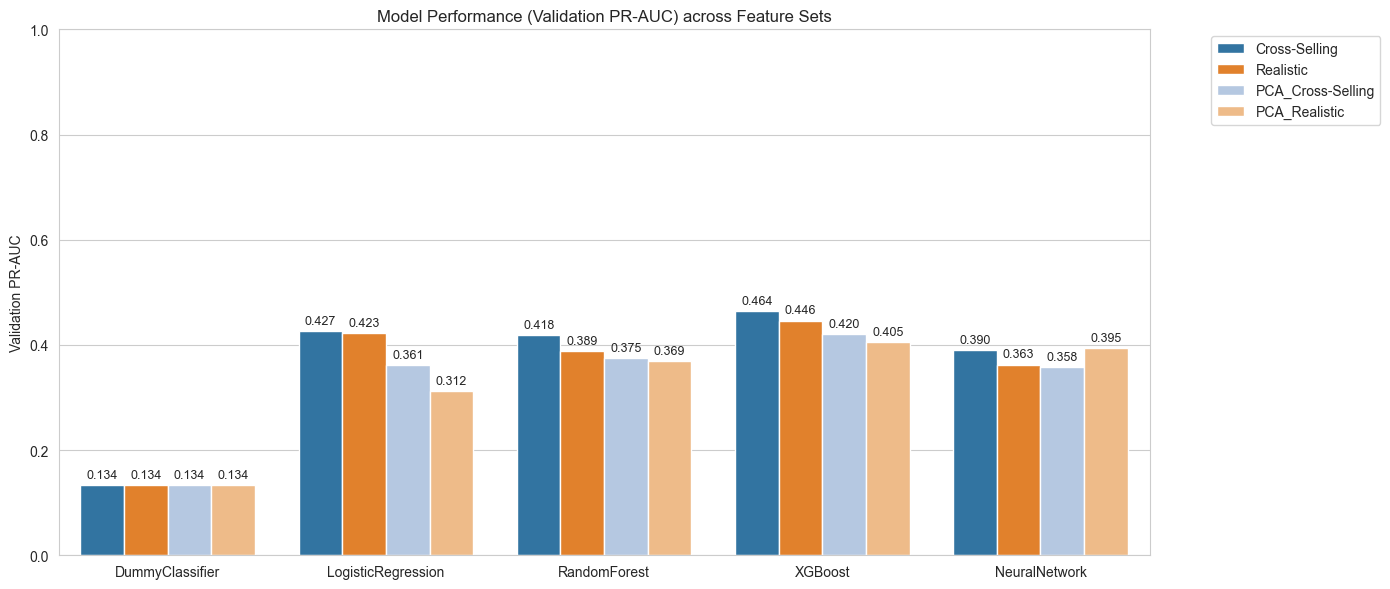

In [38]:
if not results_df.empty:
    # Keep best run for each Model-Feature_Set combo (highest Val_PR_AUC)
    results_df = (
        results_df.sort_values("Val_PR_AUC", ascending=False)
                  .drop_duplicates(subset=["Model", "Feature_Set"], keep="first")
    )

    # Custom order
    model_order = ['DummyClassifier', 'LogisticRegression', 'RandomForest', 'XGBoost', 'NeuralNetwork']
    feature_set_order = ['Cross-Selling', 'Realistic', 'PCA_Cross-Selling', 'PCA_Realistic']

    results_df["Model"] = pd.Categorical(results_df["Model"], categories=model_order, ordered=True)
    results_df["Feature_Set"] = pd.Categorical(results_df["Feature_Set"], categories=feature_set_order, ordered=True)
    results_df = results_df.sort_values(["Model", "Feature_Set"])
    # Plot
    plt.figure(figsize=(14, 6))
    ax = sns.barplot(
        data=results_df,
        x="Model",
        y="Val_PR_AUC",
        hue="Feature_Set",
        palette=color_palette
    )

    plt.title("Model Performance (Validation PR-AUC) across Feature Sets")
    plt.ylim(0, 1.0)
    plt.ylabel("Validation PR-AUC")
    plt.xlabel("")
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")

    # Add value labels on bars
    for container in ax.containers:
        ax.bar_label(container, fmt="%.3f", padding=3, fontsize=9)

    plt.tight_layout()
    plt.show()

### 4.2 Lift Calculation

While PR-AUC summarizes overall classification quality, our business case is ultimately a *ranking problem*: given a limited outreach budget, we want to prioritize individuals who are most likely to be covered exclusively by Medicaid. To evaluate this ranking ability, we compute **cumulative lift** on the **validation set** for all models.
Lift measures how much better a model performs compared to random targeting by showing how many times more Medicaid-only individuals are identified within the top-ranked share of the population. This metric is very relevant for the business case, as it directly quantifies the efficiency gains achievable when prioritizing outreach to a limited subset of individuals.

Because the lift curve is used in the final evaluation we opted to create a `get_lift_curve` function.

In [39]:
def get_lift_curve(y_true, y_prob):
    """
    Calculates cumulative lift curve.
    Returns (percentages, lift) arrays.
    """
    y_true = np.array(y_true)
    y_prob = np.array(y_prob)
    
    # Sort by predicted probability descending
    sorted_indices = np.argsort(y_prob)[::-1]
    sorted_y_true = y_true[sorted_indices]
    
    # Calculate Cumulative Gain
    cum_positives = np.cumsum(sorted_y_true)
    total_positives = cum_positives[-1]
    
    if total_positives == 0:
        return None, None
        
    cum_gain = cum_positives / total_positives
    # Percentage of population (x-axis)
    percentages = np.arange(1, len(cum_gain) + 1) / len(cum_gain)
    
    # Calculate Lift: Gain / % Population
    lift = cum_gain / percentages
    
    return percentages, lift

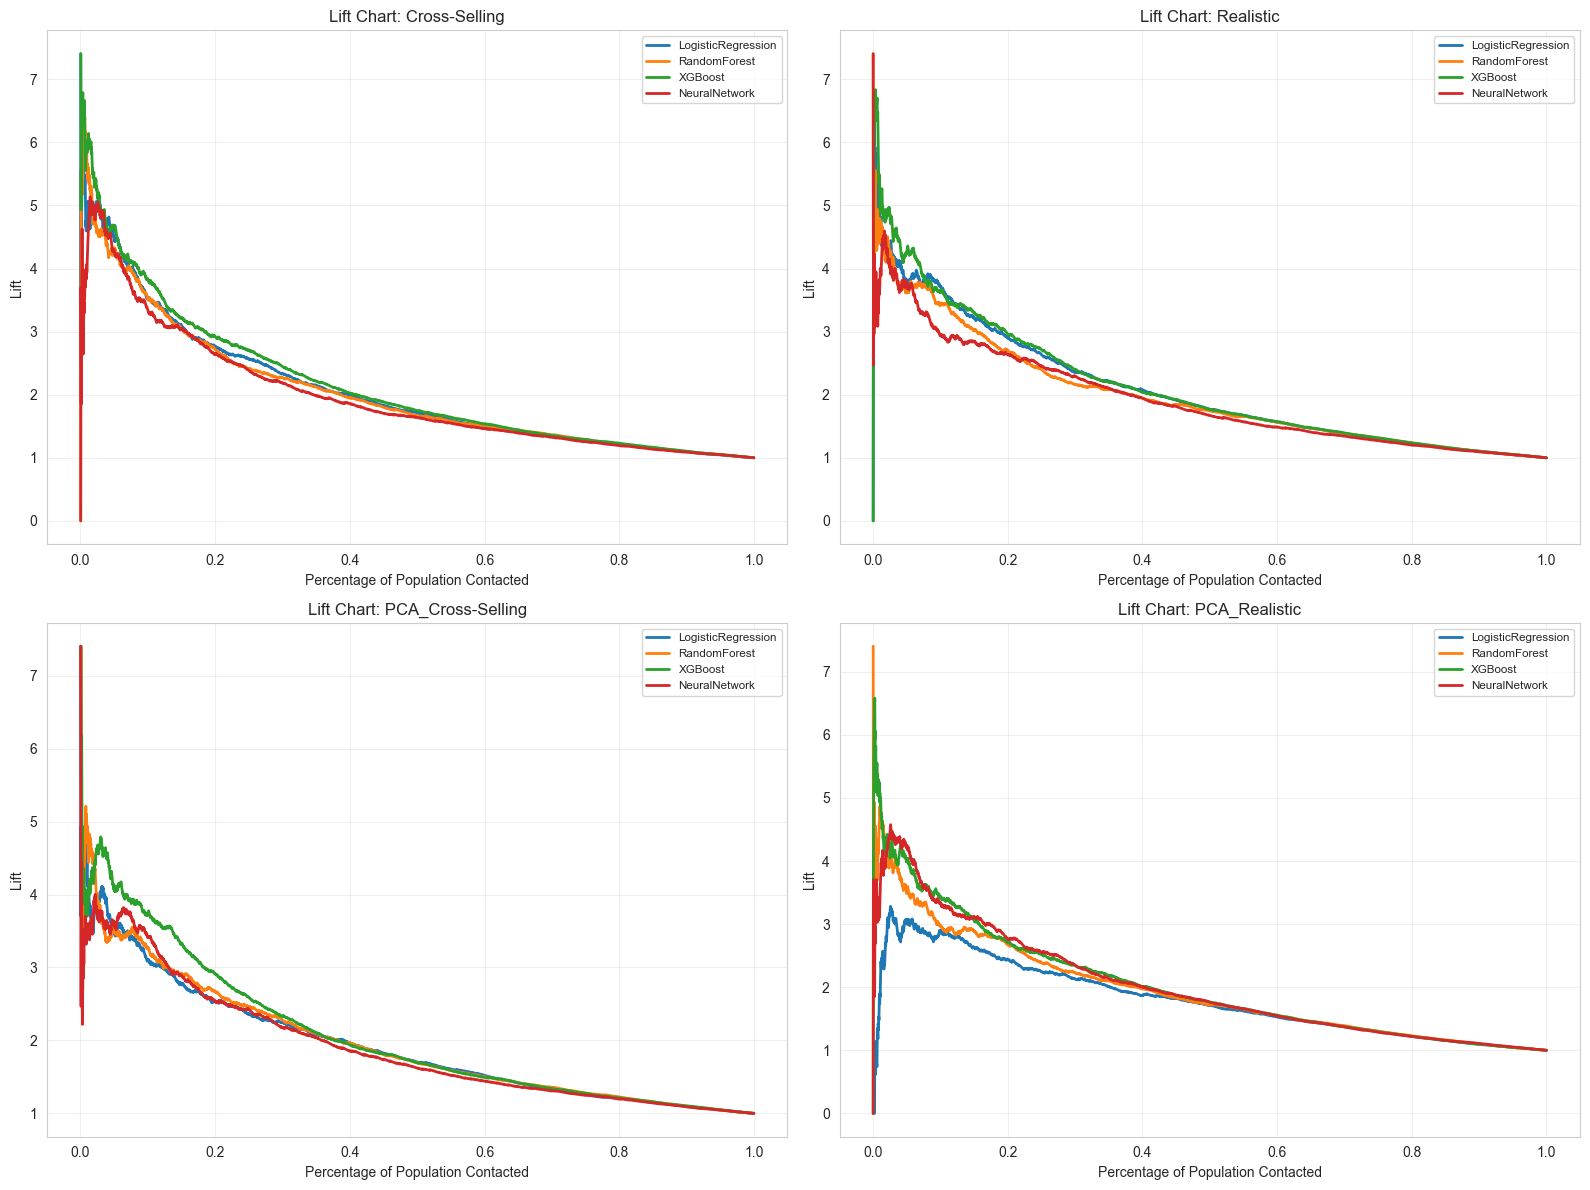

In [40]:
# Plot Lift Curves
plot_models_curve(
    models_list=all_results,
    metric_calc_fn=get_lift_curve,
    ylabel='Lift',
    title_prefix='Lift Chart',
    baseline_plot_fn=lambda ax, *args: ax.axhline(y=1, color='red', linestyle='', label='Baseline'),
    datasets=['val']
)

### 4.3 Cumulative Gain
For each selected model, we sort individuals by predicted probability of `only_medicaid` and calculate how many true positive cases are captured as we target the top of the ranked population. These gain values are visualized in a chart, enabling a direct comparison of how effectively the best approach for each feature set concentrates the minority class in the highest-ranked segments.

In [41]:
def get_cumulative_gain_curve(y_true, y_prob):
    """
    Calculates cumulative gain curve.
    Returns (percentages, gains) arrays.
    """
    y_true = np.array(y_true)
    y_prob = np.array(y_prob)
    
    # Sort by predicted probability descending
    sorted_indices = np.argsort(y_prob)[::-1]
    sorted_y_true = y_true[sorted_indices]
    
    # Calculate Cumulative Gain
    cum_positives = np.cumsum(sorted_y_true)
    total_positives = cum_positives[-1]
    
    if total_positives == 0:
        return None, None
        
    cum_gain = cum_positives / total_positives
    # Percentage of population (x-axis)
    percentages = np.arange(1, len(cum_gain) + 1) / len(cum_gain)
    
    return percentages, cum_gain

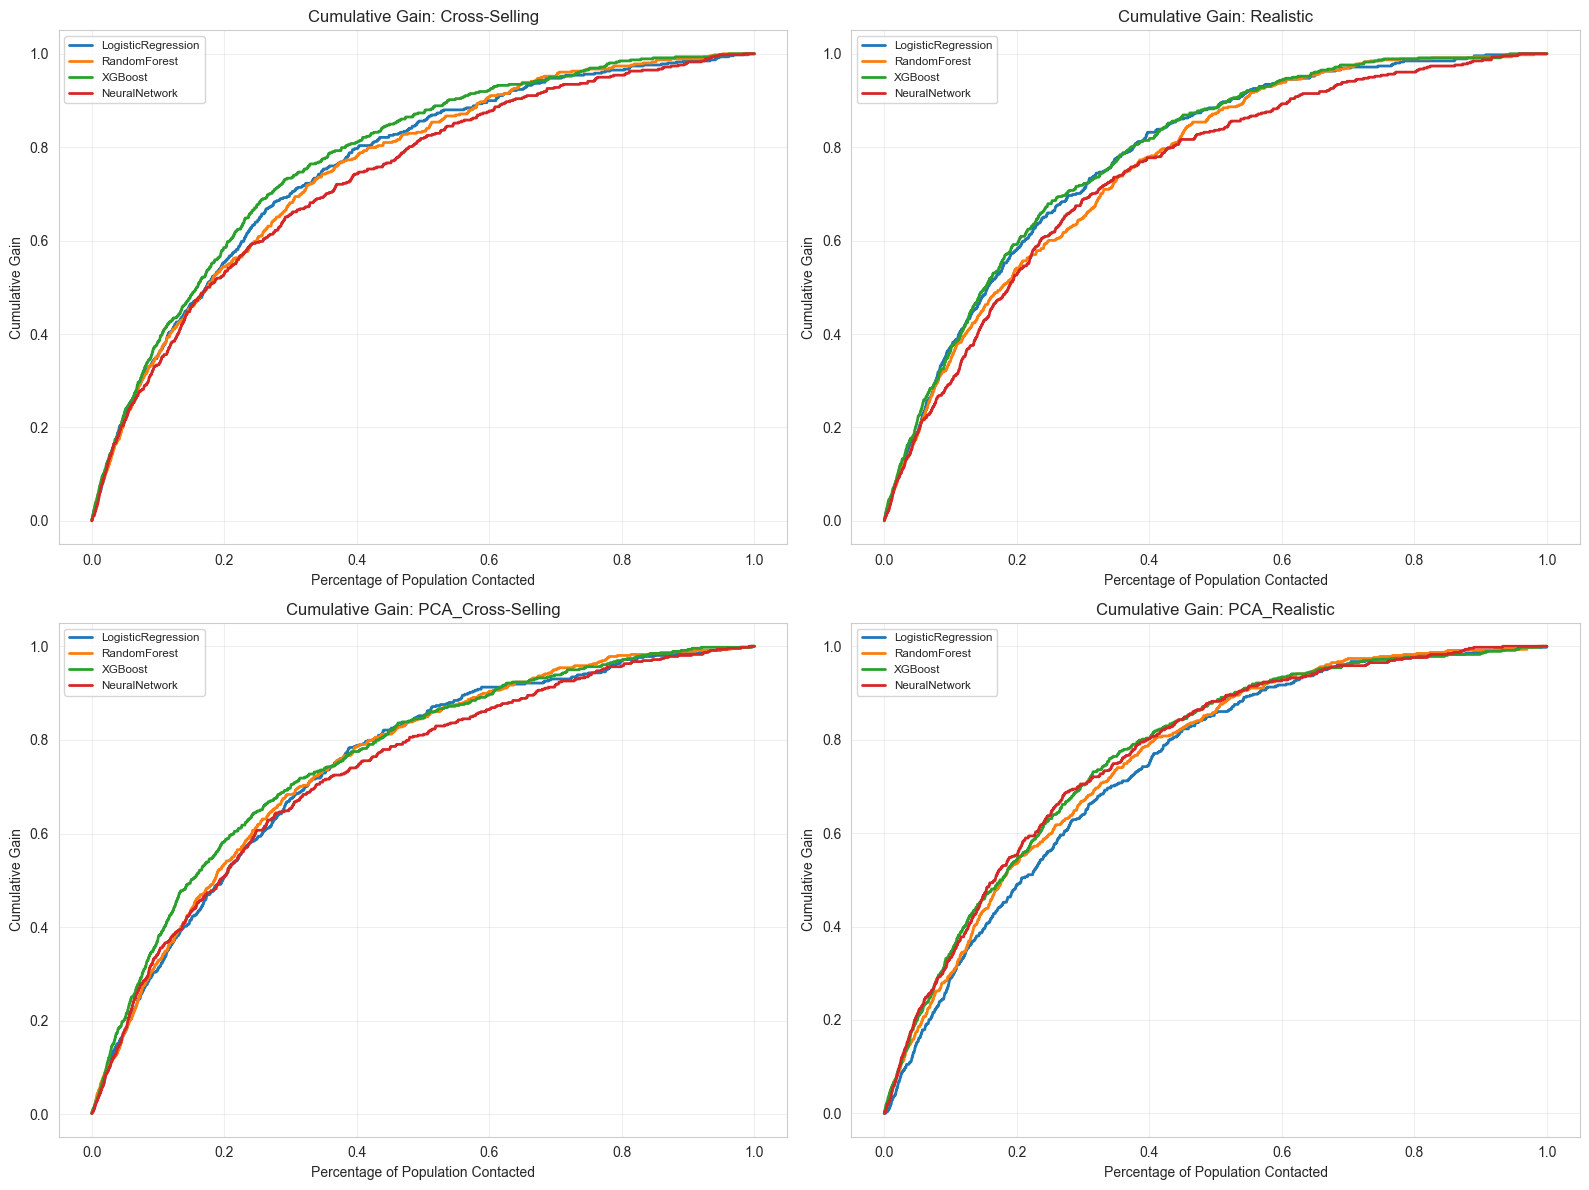

In [42]:
# Plot Cumulative Gain Curves
plot_models_curve(
    models_list=all_results,
    metric_calc_fn=get_cumulative_gain_curve,
    ylabel='Cumulative Gain',
    title_prefix='Cumulative Gain',
    baseline_plot_fn=lambda ax, *args: ax.plot([0, 1], [0, 1], 'r:', label='Baseline'),
    datasets=['val']
)

### 4.4 Profitability Analysis

To assess the practical business value of our models, we perform apply a **profit curve** that compares the **cost of outreach** and in the case of the realistic set the **cost of dataset** against the **expected benefit** from acquiring a new customer. The objective is to quantify how strong the model’s targeting performance (i.e., lift or precision among contacted individuals) must be for outreach efforts to become profitable.

**Scenario parameters (assumptions):**
- **Customer lifetime value:**  
  - Profit per year: **$34**  
  - Assumed customer lifetime: **10 years**  
  - **Total profit per sale:** **$340**
- **Conversion rate when contacting the “right person” (true positive):**  
  - **3%** probability of a successful sale
- **Outreach (cold call) effort:**  
  - Average call duration: **2:52**  
  - Calls per hour: **21**
- **Cost of outreach:**  
  - Hourly wage of outreach agent: **$30**  
  - **Cost per contact:** **$1.43**
- **Fixed data cost:**  
  - Cost per record (e.g., data broker fee): **$0.05** per individual
- **US Call center cost (reference):**  
  - **$30–$40** per hour (used as a benchmark)
- **Derived metrics:**
  - Expected benefit per correctly identified individual: **$10.20**
  - Required precision to break even: **14.01%**

Using these assumptions, we compute the expected benefit of contacting correctly identified individuals and determine the **maximum profit**. We then compare the profitability of the different models per feature set. 

The results are used to select the best-performing models, with profitability as the primary metric, given its critical role in the business case.


In [43]:
def calculate_profit_curve(y_true, y_prob, cost_per_contact, fixed_cost_total, benefit_per_tp):
    """
    Calculates the profit curve.
    Returns (x_axis_percentage, profit_curve).
    """
    y_true = np.array(y_true)
    y_prob = np.array(y_prob)
    n = len(y_true)
    
    # Sort by probability
    sorted_indices = np.argsort(y_prob)[::-1]
    sorted_y_true = y_true[sorted_indices]
    
    # Cumulative Benefit
    cum_tp = np.cumsum(sorted_y_true)
    benefit = cum_tp * benefit_per_tp
    
    # Cumulative Cost
    cum_contacted = np.arange(1, n + 1)
    cost = cum_contacted * cost_per_contact + fixed_cost_total
    
    # Profit
    profit = benefit - cost
    
    # X-axis
    x_axis = cum_contacted / n
    
    return x_axis, profit


Best Models by Profit:
  Cross-Selling: XGBoost (Max Profit: $2,004.14 at 29.2% of population)
  Realistic: XGBoost (Max Profit: $1,805.51 at 24.7% of population)
  PCA_Cross-Selling: XGBoost (Max Profit: $1,834.60 at 30.1% of population)
  PCA_Realistic: XGBoost (Max Profit: $1,732.91 at 34.0% of population)


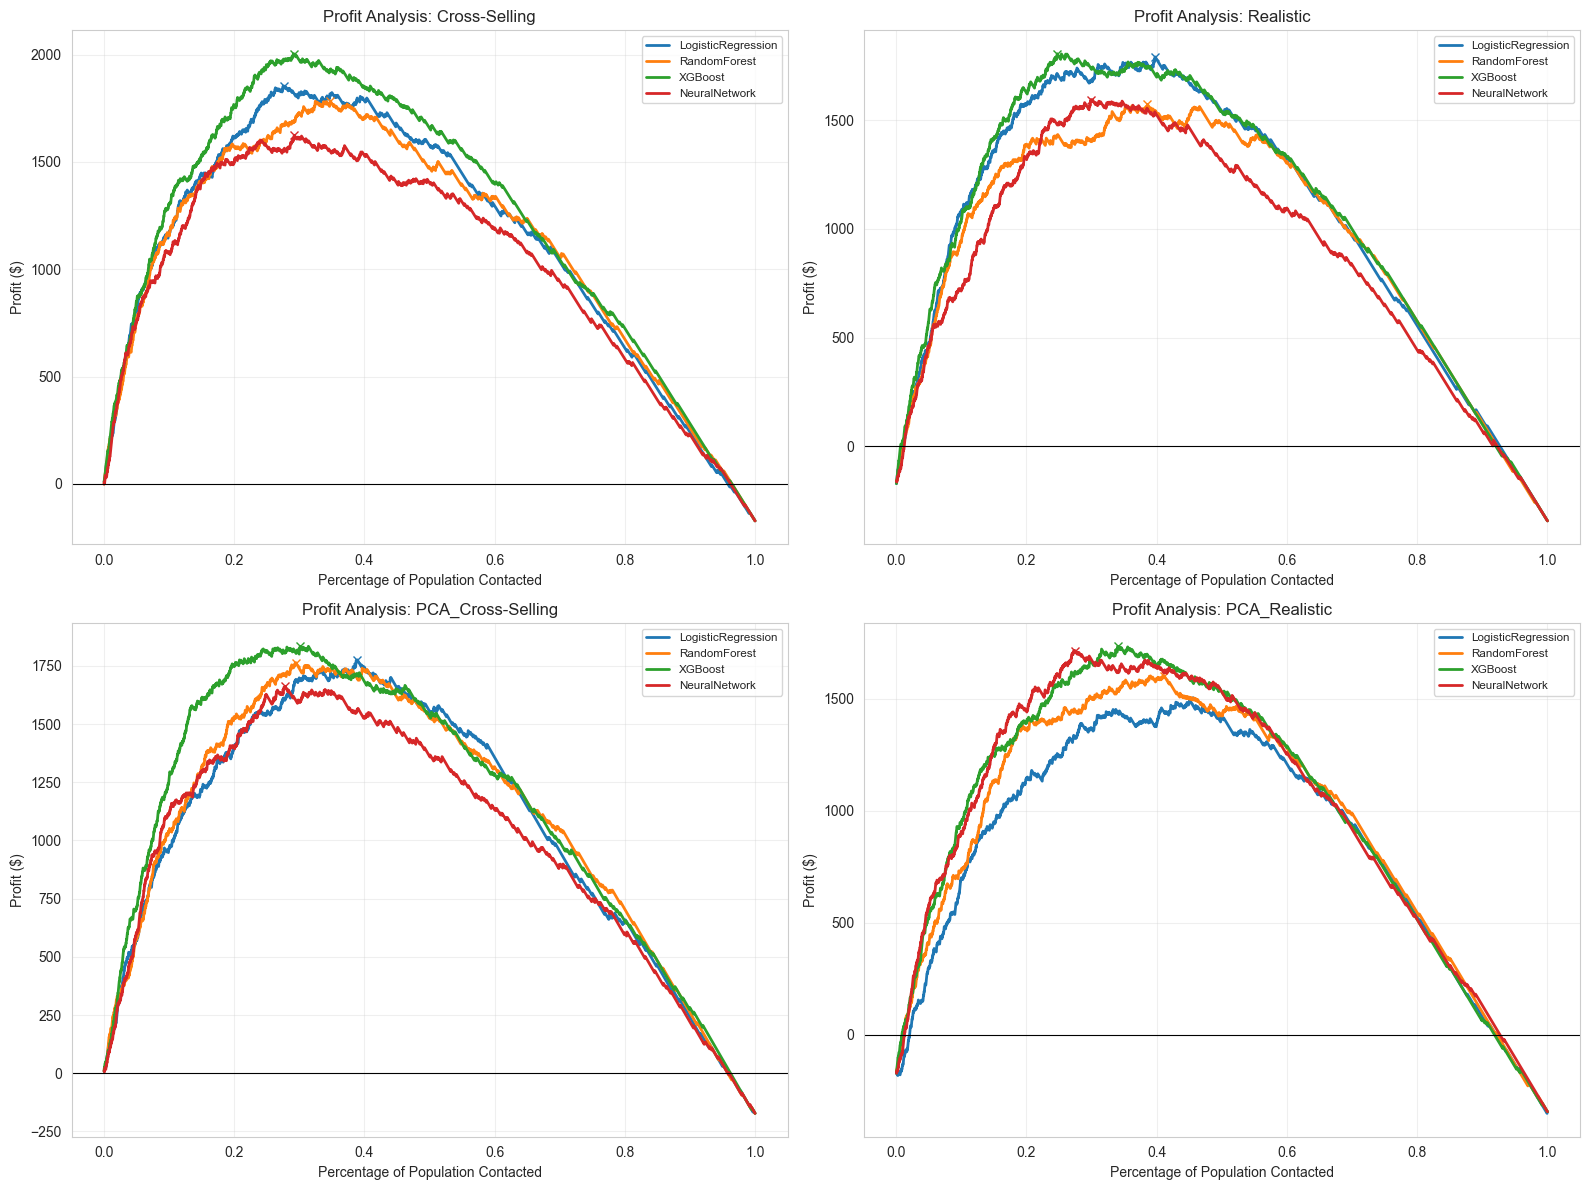

In [63]:
# Constants from the problem description
profit_per_sale = 34 * 10 # $340 Lifetime Value
conversion_rate_right_person = 0.03 # 3% chance of sale if we contact the "Right Person" (True Positive)
calls_per_hour = 21
hourly_wage = 30
cost_per_record = 0.05

# Calculate Cost and Benefit per unit
cost_per_contact = hourly_wage / calls_per_hour
# Expected benefit of finding a "Right Person" = Value of Sale * Probability of Sale
expected_benefit_per_right_person = profit_per_sale * conversion_rate_right_person
best_model_list = []

def profit_metric_wrapper(y_true, y_prob, fixed_cost=None):
    """Wrapper to pass extra args to calculate_profit_curve"""
    if fixed_cost is None:
        fix_cost = cost_per_record * len(y_true)
    else:
        fix_cost = fixed_cost
    return calculate_profit_curve(y_true, y_prob, cost_per_contact, fix_cost, expected_benefit_per_right_person)


# Identify Best Models based on Profit
print("Best Models by Profit:")
target_feature_sets = ['Cross-Selling', 'Realistic', 'PCA_Cross-Selling', 'PCA_Realistic']

for fs in target_feature_sets:
    fs_models = [m for m in all_results if m['Feature_Set'] == fs]
    best_profit = -np.inf
    best_pct = 0
    best_model = None
    
    for m in fs_models:
        if m['Model'] == 'DummyClassifier': continue
        
        if fs in data_splits:
            y_test = data_splits[fs]['y_val']
            model_instance = m['Model_Instance']
            y_prob = get_model_probs(model_instance, data_splits[fs]['X_val'])
            
            # Determine fixed cost
            if 'Realistic' in fs:
                fix_cost = cost_per_record * len(y_test)
            else:
                fix_cost = 0
            
            pct_curve, profit_curve = profit_metric_wrapper(y_test, y_prob, fixed_cost=fix_cost)
            max_idx = np.argmax(profit_curve)
            max_p = profit_curve[max_idx]
            max_pct_val = pct_curve[max_idx]
            
            if max_p > best_profit:
                best_profit = max_p
                best_pct = max_pct_val
                best_model = m
    
    if best_model:
        print(f"  {fs}: {best_model['Model']} (Max Profit: ${best_profit:,.2f} at {best_pct:.1%} of population)")
        best_model_list.append(best_model)

# Plot Profit Curves
plot_models_curve(
    models_list=all_results,
    metric_calc_fn=profit_metric_wrapper,
    ylabel='Profit ($)',
    title_prefix='Profit Analysis',
    mark_max=True,
    datasets=['val']
)

For each feature set, we select a single best-performing model for further evaluation in Section 5, thereby reducing the initial 16 model–feature set combinations to four. A model is defined as *best* if it achieves the highest expected profit under the business scenario described in the cost–benefit analysis (Section 4.4). This selection criterion ensures that the final comparison is driven not only by predictive performance, but also by practical economic relevance for targeted insurance outreach.

---

## 5. Evaluation (Test Performance)

In this section, we evaluate the performance of the four selected best model–feature set combinations (as identified in Section 4.4) using the **held-out test set**. The objective is to assess both their generalization performance and their practical usefulness for the business case of targeted insurance outreach.

> *Section 5.1 provides an overall performance overview based on **test-set PR-AUC** scores and contrasts these results with the corresponding **validation-set PR-AUC** values. Section 5.2 analyzes lift calculations for the four best-performing models to quantify improvements over random targeting. Section 5.3 examines cumulative gain curves to assess how effectively the models rank individuals by their likelihood of being covered exclusively by Medicaid. Finally, Section 5.4 performs a comparative profitability analysis on the validation and test sets to evaluate whether business-oriented performance estimates generalize to unseen data.*

### 5.1 Model Comparison (Test PR-AUC)

After selecting and comparing models based on validation performance, we assess their **generalization ability** using the **held-out test set**, which has not been used during training or model selection. This step provides an unbiased estimate of how well each model–feature set combination is expected to perform on unseen data. Unlike Section 4.1, this section focuses on test-set performance and reflects final model quality.

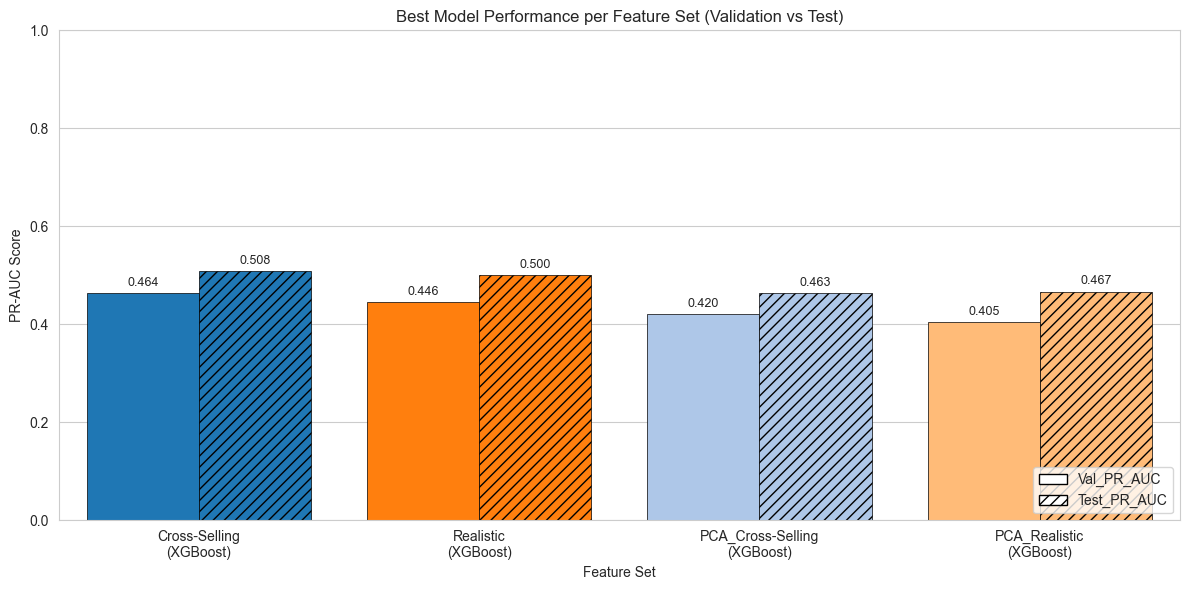

In [45]:
def get_model_probs(model, X):
    """Helper to get probabilities or predictions from a model."""
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]
    return model.predict(X)

# Create a set of best models for fast lookup
best_models_set = {(item['Feature_Set'], item['Model']) for item in best_model_list}

test_results = []

for res in all_results:
    # Filter: Only process if it's one of the best models
    if (res['Feature_Set'], res['Model']) not in best_models_set:
        continue

    fs = res['Feature_Set']
    # Ensure we have the data
    if fs in data_splits:
        split_data = data_splits[fs]
        X_test, y_test = split_data['X_test'], split_data['y_test']
        X_val, y_val = split_data['X_val'], split_data['y_val']
        
        model = res['Model_Instance']

        # Get Predictions
        y_prob_test = get_model_probs(model, X_test)
        y_prob_val = get_model_probs(model, X_val)
        
        # Calculate Validation Profit
        if 'Realistic' in fs:
            fix_cost_val = cost_per_record * X_val.shape[0]
        else:
            fix_cost_val = 0
            
        _, profit_val = calculate_profit_curve(
            np.array(y_val), 
            y_prob_val, 
            cost_per_contact, 
            fix_cost_val, 
            expected_benefit_per_right_person
        )

        test_results.append({
            'Model': res['Model'],
            'Feature_Set': fs,
            'Val_PR_AUC': res['Val_PR_AUC'],
            'Test_PR_AUC': average_precision_score(y_test, y_prob_test),
            'Val_Max_Profit': np.max(profit_val)
        })

# Create DataFrame
results_df = pd.DataFrame(test_results)

# Define plotting order
feature_set_order = ['Cross-Selling', 'Realistic', 'PCA_Cross-Selling', 'PCA_Realistic']
model_order = ['DummyClassifier', 'LogisticRegression', 'RandomForest', 'XGBoost', 'NeuralNetwork']

# Prepare data for plotting
plot_df = results_df.melt(
    id_vars=["Feature_Set", "Model"], 
    value_vars=["Val_PR_AUC", "Test_PR_AUC"], 
    var_name="Metric", 
    value_name="PR_AUC"
)

# Plot
plt.figure(figsize=(12, 6))
ax = sns.barplot(
    data=plot_df,
    x="Feature_Set",
    y="PR_AUC",
    hue="Metric",
    order=feature_set_order
)

# Customize colors and hatches
hatches = ['', '///']

# Check if color_palette is defined, otherwise use default
if 'color_palette' not in locals():
    color_palette = {} # Fallback

for i, container in enumerate(ax.containers):
    for j, bar in enumerate(container):
        # Ensure we don't go out of bounds if feature_set_order has more items than bars
        if j < len(feature_set_order):
            fs_name = feature_set_order[j]
            col = color_palette.get(fs_name, 'gray')
            bar.set_facecolor(col)
            bar.set_hatch(hatches[i % len(hatches)])
            bar.set_edgecolor('black')
            bar.set_linewidth(0.5)
    ax.bar_label(container, fmt="%.3f", padding=3, fontsize=9)

plt.title("Best Model Performance per Feature Set (Validation vs Test)")
plt.ylim(0, 1.0)
plt.ylabel("PR-AUC Score")
plt.xlabel("Feature Set")

# Custom Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='white', edgecolor='black', label='Val_PR_AUC'),
    Patch(facecolor='white', edgecolor='black', hatch='///', label='Test_PR_AUC')
]
plt.legend(handles=legend_elements, loc='lower right')

# Update x-axis labels to include the model name
new_labels = []
for label in ax.get_xticklabels():
    fs_name = label.get_text()
    # Find the model for this feature set
    match = results_df[results_df['Feature_Set'] == fs_name]
    if not match.empty:
        model_name = match['Model'].values[0]
        new_labels.append(f"{fs_name}\n({model_name})")
    else:
        new_labels.append(fs_name)

ax.set_xticklabels(new_labels)

plt.tight_layout()
plt.show()

### 5.2 Best Model Lift Calculation

Next, we compute and visualize **cumulative lift curves** for the best-performing model of each feature set.

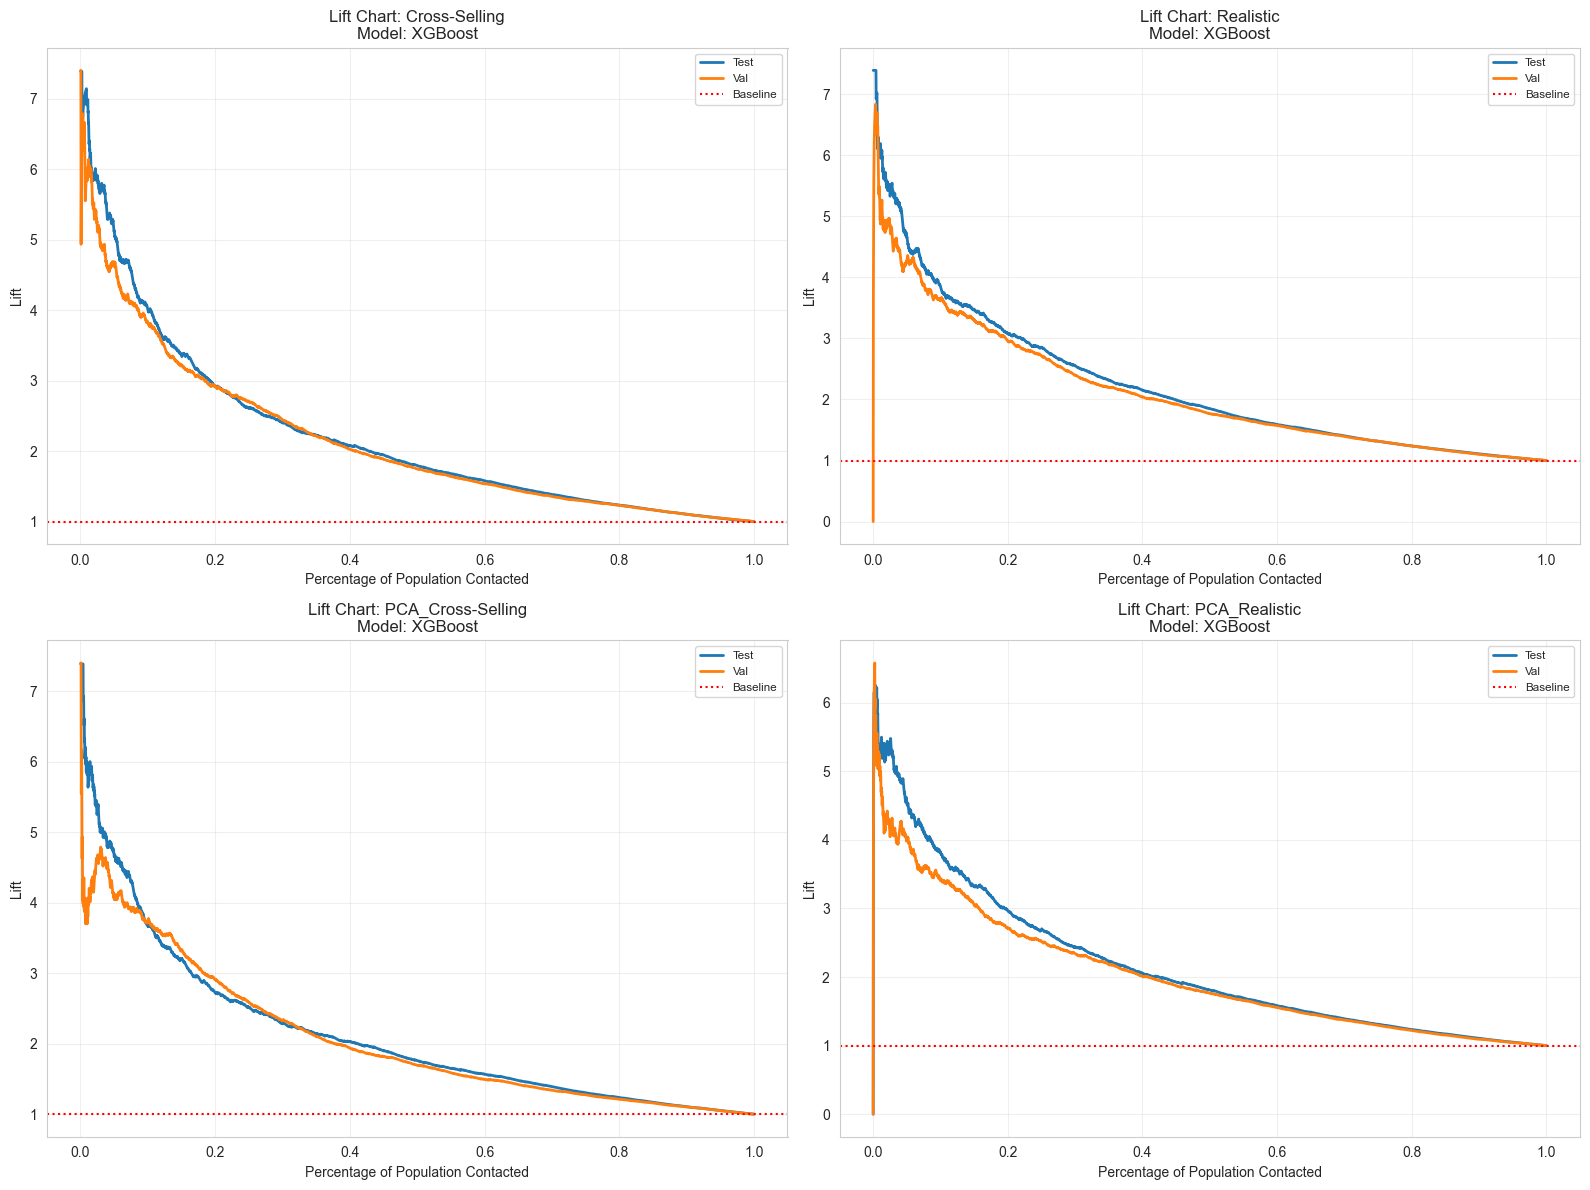

In [46]:
# Plot Lift Curves
plot_models_curve(
    models_list=best_model_list,
    metric_calc_fn=get_lift_curve,
    ylabel='Lift',
    title_prefix='Lift Chart',
    baseline_plot_fn=lambda ax, *args: ax.axhline(y=1, color='red', linestyle=':', label='Baseline'),
    datasets=['val','test']
)

### 5.3 Best Model Cumulative Gain

The **full cumulative gain curves** for the best model for each feature-set illustrate how effectively each model ranks individuals by likelihood of being covered exclusively by Medicaid across the entire population, and allow a direct comparison against a random targeting baseline.

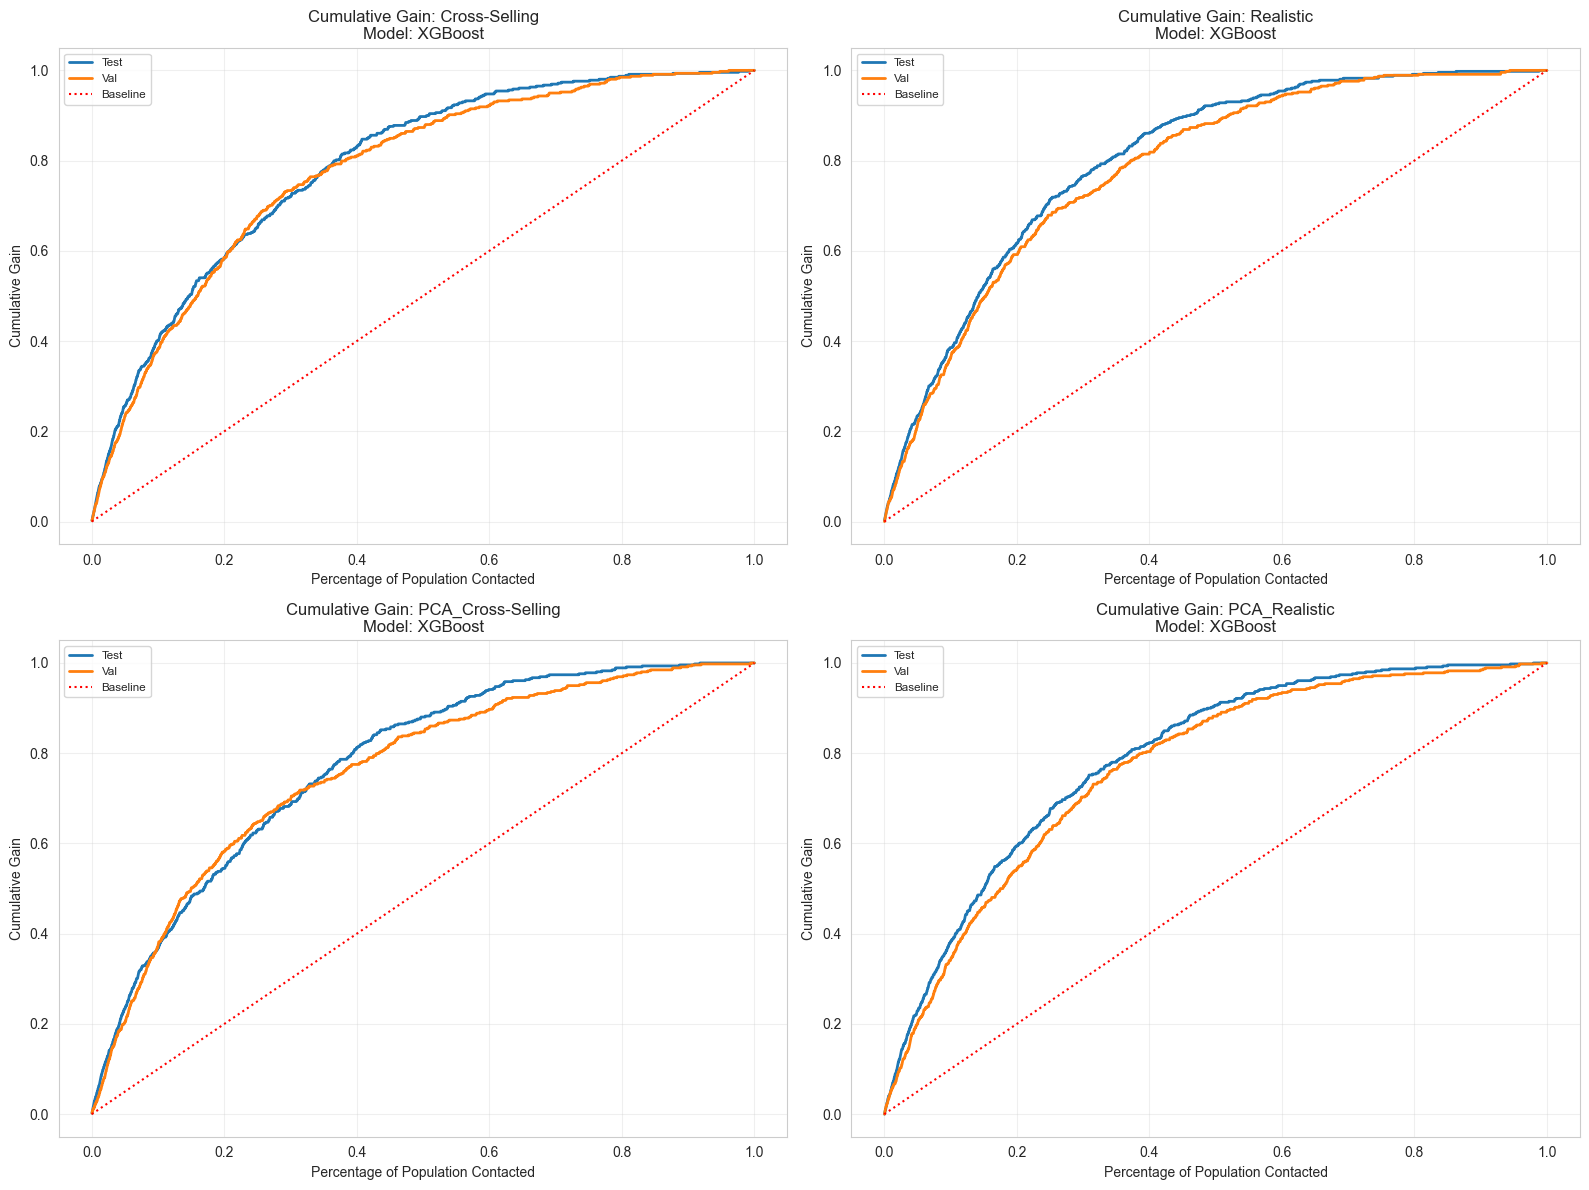

In [47]:
# Plot Cumulative Gain Curves
plot_models_curve(
    models_list=best_model_list,
    metric_calc_fn=get_cumulative_gain_curve,
    ylabel='Cumulative Gain',
    title_prefix='Cumulative Gain',
    baseline_plot_fn=lambda ax, *args: ax.plot([0, 1], [0, 1], 'r:', label='Baseline'),
    datasets=['val','test']
)

### 5.4 Profitability Analysis (Validation vs. Test)

Finally, we repeat the profitability analysis introduced in Section 4.4, restricting the comparison to the four selected best-performing model–feature set combinations. For each model, we compute the expected profit curves separately on the validation and test sets and compare the resulting maximum achievable profits. This comparison allows us to assess whether profitability estimates derived during model selection generalize to unseen data, and whether any models exhibit signs of overfitting when evaluated from a business perspective.

Max Profit Analysis (Best Models):
Feature Set: Cross-Selling | Model: XGBoost
  Max Profit (Val):  $2,004.14 (at 29.2% of population)
  Max Profit (Test): $1,992.09 (at 40.8% of population)
------------------------------
Feature Set: Realistic | Model: XGBoost
  Max Profit (Val):  $1,805.51 (at 24.7% of population)
  Max Profit (Test): $1,969.17 (at 29.7% of population)
------------------------------
Feature Set: PCA_Cross-Selling | Model: XGBoost
  Max Profit (Val):  $1,834.60 (at 30.1% of population)
  Max Profit (Test): $1,875.34 (at 43.6% of population)
------------------------------
Feature Set: PCA_Realistic | Model: XGBoost
  Max Profit (Val):  $1,732.91 (at 34.0% of population)
  Max Profit (Test): $1,852.26 (at 30.9% of population)
------------------------------


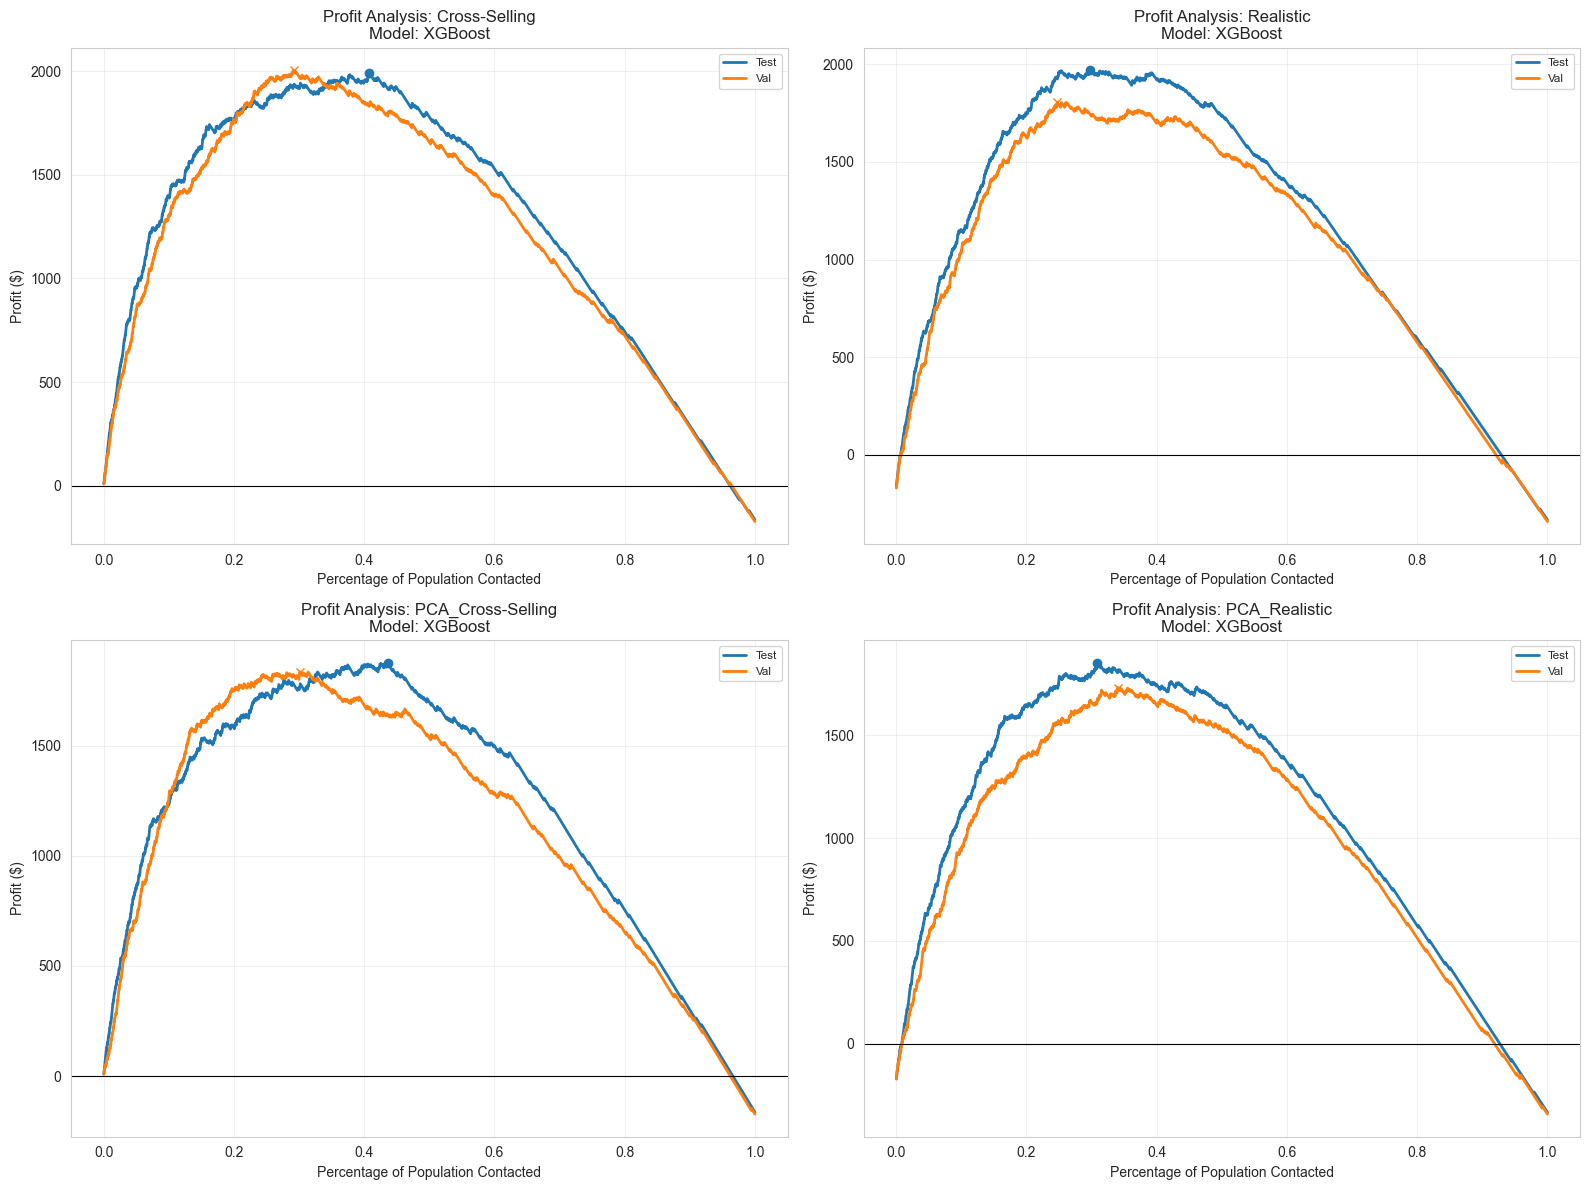

In [64]:
# Print Max Profit for Validation and Test Sets
print("Max Profit Analysis (Best Models):")
for model_entry in best_model_list:
    fs = model_entry['Feature_Set']
    model_name = model_entry['Model']
    model = model_entry['Model_Instance']
    
    if fs in data_splits:
        # Validation
        X_val = data_splits[fs]['X_val']
        y_val = data_splits[fs]['y_val']
        y_prob_val = get_model_probs(model, X_val)
        
        # Determine fixed cost for Validation
        if 'Realistic' in fs:
            fix_cost_val = cost_per_record * len(y_val)
        else:
            fix_cost_val = 0
            
        pct_val, profit_val = profit_metric_wrapper(y_val, y_prob_val, fixed_cost=fix_cost_val)
        max_idx_val = np.argmax(profit_val)
        max_profit_val = profit_val[max_idx_val]
        max_pct_val = pct_val[max_idx_val]
        
        # Test
        X_test = data_splits[fs]['X_test']
        y_test = data_splits[fs]['y_test']
        y_prob_test = get_model_probs(model, X_test)
        
        # Determine fixed cost for Test
        if 'Realistic' in fs:
            fix_cost_test = cost_per_record * len(y_test)
        else:
            fix_cost_test = 0
            
        pct_test, profit_test = profit_metric_wrapper(y_test, y_prob_test, fixed_cost=fix_cost_test)
        max_idx_test = np.argmax(profit_test)
        max_profit_test = profit_test[max_idx_test]
        max_pct_test = pct_test[max_idx_test]
        
        print(f"Feature Set: {fs} | Model: {model_name}")
        print(f"  Max Profit (Val):  ${max_profit_val:,.2f} (at {max_pct_val:.1%} of population)")
        print(f"  Max Profit (Test): ${max_profit_test:,.2f} (at {max_pct_test:.1%} of population)")
        print("-" * 30)

# Plot Profit Curves
# Note: plot_models_curve might need adjustment if it calls metric_calc_fn without fixed_cost logic internally.
# However, since we can't easily pass dynamic kwargs per dataset inside the standard plot function without modifying it,
# we will assume for now the plot function uses the default wrapper behavior or we accept the limitation for the plot.
# If strict correctness for the plot is needed, we would need to modify plot_models_curve or create a custom wrapper per model.
plot_models_curve(
    models_list=best_model_list,
    metric_calc_fn=profit_metric_wrapper,
    ylabel='Profit ($)',
    title_prefix='Profit Analysis',
    mark_max=True,
    datasets=['val','test']
)

---

## 6. Fairness Evaluation

We evaluate the fairness of our best-performing model using the **Fairlearn** library, supplemented by manual calculations. Given that the Census data contains sensitive demographic attributes, we specifically focus on fairness metrics related to groups defined by **Age**, **Sex**, **Race**, **Disability**, and **Marital Status**.

The key metrics evaluated include:
*   **Equalized Odds Difference (EOD)**
*   **Demographic Parity Ratio (DPR)** 

**Assessment Threshold**
To assess potential adverse impact, we use the **Four-Fifths Rule**. A Demographic Parity Ratio (or Disparate Impact) value below **0.8** indicates that the model may be disproportionately disadvantaging a specific demographic group. In addition, we set an Equalized Odds Difference (EOD) threshold of **0.1**, above which the model is considered to exhibit significant disparities in true positive and false positive rates across groups.

In [49]:
# Settings
MIN_N = 50
DI_MIN = 0.80
EOD_MAX = 0.10  

attrs = ['AGEP', 'age_group', 'SEX', 'MAR', 'marital_status_simple', 'MIG', 'NATIVITY', 'RAC1P', 'HISP', 'has_any_disability']
mappings = {
    "SEX": {1: "Male", 2: "Female"},
    "RAC1P": {1: "White", 2: "Black", 3: "Amer. Indian", 4: "Alaska Native", 5: "Amer. Indian/Alaska", 6: "Asian", 7: "Native Hawaiian", 8: "Other Pacific Isl.", 9: "Two or More"},
    "MAR": {1: "Married", 2: "Widowed", 3: "Divorced", 4: "Separated", 5: "Never married"},
    "MIG": {1: "Same house", 2: "Outside US/PR", 3: "Different house US/PR"},
    "NATIVITY": {1: "Native", 2: "Foreign born"},
    "HISP": {1: "Not Hispanic"},
    "has_any_disability": {0: "No", 1: "Yes"}
}

for model_entry in best_model_list:
    fs_name = model_entry['Feature_Set']
    model_name = model_entry['Model']
    model = model_entry['Model_Instance']


# Get appropriate test set
if fs_name in data_splits:
    X_eval = data_splits[fs_name]['X_test']
    y_eval = data_splits[fs_name]['y_test']
else:
    X_eval, y_eval = X_test, y_test

# Predict
if hasattr(model, "predict_proba"):
    y_prob = model.predict_proba(X_eval)[:, 1]
    y_pred = (y_prob >= 0.5).astype(int)
else:
    y_pred = model.predict(X_eval)

# Ensure indexed Series (so masking works safely)
y_eval_s = pd.Series(y_eval, index=X_eval.index)
y_pred_s = pd.Series(y_pred, index=X_eval.index)

# Helper to prepare sensitive features
def get_sensitive_feature(attr, df, index):
    s = df.loc[index, attr].copy()
    if attr in mappings:
        s = s.map(mappings[attr]).fillna(s)
    return s.astype(str)

rows = []
for attr in [a for a in attrs if a in df_2_3.columns]:
    s = get_sensitive_feature(attr, df_2_3, X_eval.index)

    # Enforce MIN_N per group (drop underpowered groups for this attribute)
    counts = s.value_counts(dropna=False)
    mask = s.map(counts) >= MIN_N

    # If too little data or only one group remains, skip
    if mask.sum() < MIN_N or s[mask].nunique() < 2:
        rows.append({
            "Attribute": attr,
            "DI (min/max)": np.nan,
            "EOD": np.nan,
            "N_used": int(mask.sum()),
            "Groups_used": int(s[mask].nunique()),
            "Decision": "SKIP (insufficient group support)"
        })
        continue

    s_f = s[mask]
    y_true_f = y_eval_s[mask]
    y_pred_f = y_pred_s[mask]

    # Two metrics only
    di = demographic_parity_ratio(y_true_f, y_pred_f, sensitive_features=s_f)   # min(selection_rate)/max(selection_rate)
    eod = equalized_odds_difference(y_true_f, y_pred_f, sensitive_features=s_f) # max gap in TPR/FPR across groups

    # Decision rule: UNFAIR if DI < 0.80 OR EOD > 0.10
    passes_di = di >= DI_MIN
    passes_eod = eod <= EOD_MAX
    decision = "PASS" if (passes_di and passes_eod) else "FAIL"

    rows.append({
        "Attribute": attr,
        "DI (min/max)": di,
        "EOD": eod,
        "DI_pass": passes_di,
        "EOD_pass": passes_eod,
        "Decision": decision
    })

fairness_df = pd.DataFrame(rows)

print(f"\nFairness Screen (2 metrics): DI >= {DI_MIN} and EOD <= {EOD_MAX} (MIN_N per group = {MIN_N})")
display(fairness_df.round(4))


Fairness Screen (2 metrics): DI >= 0.8 and EOD <= 0.1 (MIN_N per group = 50)


,Attribute,DI (min/max),EOD,DI_pass,EOD_pass,Decision
0,AGEP,0.2181,1.0000,False,False,FAIL
1,age_group,0.3599,0.4208,False,False,FAIL
2,SEX,0.8401,0.0625,True,True,PASS
3,MAR,0.1758,0.4951,False,False,FAIL
4,marital_status_simple,0.1758,0.4951,False,False,FAIL
5,MIG,0.6971,0.1248,False,False,FAIL
6,NATIVITY,0.9555,0.2686,True,False,FAIL
7,RAC1P,0.3586,0.4111,False,False,FAIL
8,HISP,0.5288,0.2585,False,False,FAIL
9,has_any_disability,0.5033,0.2344,False,False,FAIL


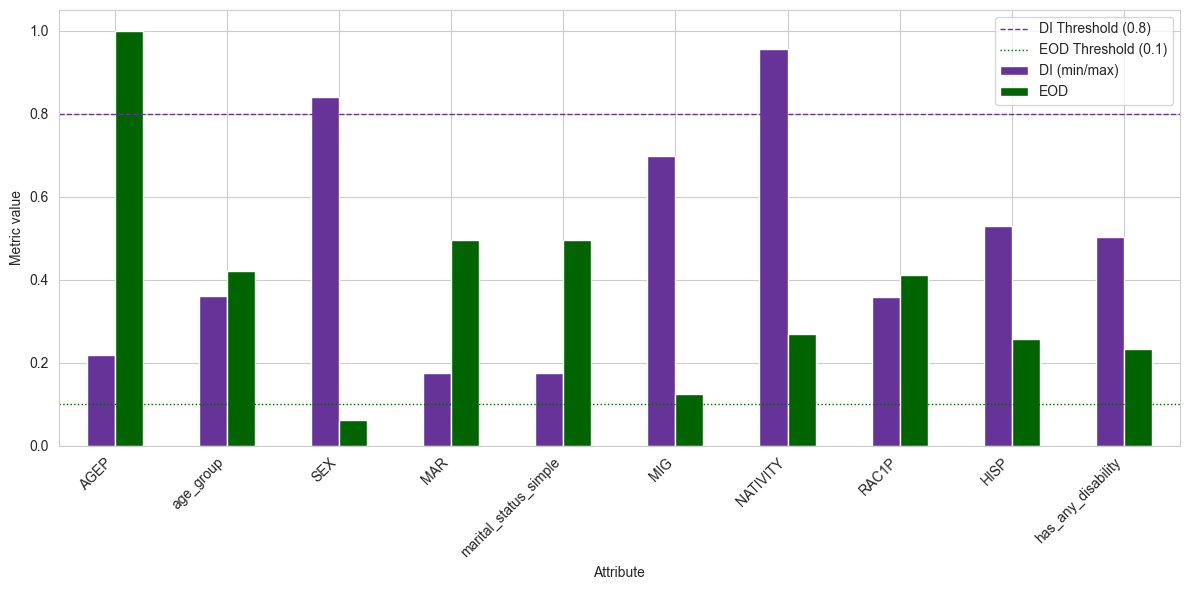

In [59]:
# Plot only rows where both metrics exist (skip attributes flagged as SKIP)
plot_df = fairness_df.dropna(subset=["DI (min/max)", "EOD"]).copy()

ax = (
    plot_df.plot(
        x="Attribute",
        y=["DI (min/max)", "EOD"],
        kind="bar",
        figsize=(12, 6),
        color=["rebeccapurple", "darkgreen"],
    )
)

# Threshold lines (match the 2-metric gate)
ax.axhline(DI_MIN, linestyle="--", color="rebeccapurple", linewidth=1, label=f"DI Threshold ({DI_MIN})")
ax.axhline(EOD_MAX, linestyle=":", color="darkgreen", linewidth=1, label=f"EOD Threshold ({EOD_MAX})")

ax.set_ylabel("Metric value")
ax.legend()
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


---

## 7. Re-Training without Unfair Demographic Features

To mitigate potential bias and improve fairness, we defined new feature sets that exclude specific sensitive attributes. While re-binning critical unfair features was considered out of scope, we created "fair" versions of our **Realistic** and **Cross-Selling** feature sets by removing these attributes entirely.

To prepare the data for re-training, we re-executed the Data Pipeline:

1.  **Defining Fair Feature Sets**: We curated feature sets that explicitly exclude sensitive demographic variables.
2.  **Preprocessing**: We generated the new feature sets (`Cross-Selling_Fair`, `Realistic_Fair`) by applying the updated feature selections.

In [51]:
cols_cross_selling_fair = [
    'WAGP', 'SEMP', 'income_source_count', 'has_wage_income', 'has_self_employment',
    'WKL', 'OCCP_2digit', 'INDP_2digit', 'employment_status_simple', 'employer_type', 'SEX',
    'education_level', 'currently_enrolled',
    'STATE', 'PUMA'
]

feature_sets_fair = {}

if 'df_2_3' in locals():
    # Cross-Selling Fair
    X_cs_fair, y_cs_fair = preprocess_set(df_2_3, cols_cross_selling_fair, "Cross-Selling_Fair")
    feature_sets_fair['Cross-Selling_Fair'] = (X_cs_fair, y_cs_fair)
    
    # Display shapes
    print("Feature Sets Created:")
    for name, (X, y) in feature_sets_fair.items():
        print(f"  {name:<20}: {X.shape[1]} features, {X.shape[0]} rows")
else:
    print("Error: df_2_3 not found. Please run previous cells.")

# Split datasets
data_splits_fair = {}

print("\n--- Splitting Data ---")
for set_name, (X, y) in feature_sets_fair.items():
    X_train, X_val, X_test, y_train, y_val, y_test = split_dataset(X, y)
    
    data_splits_fair[set_name] = {
        'X_train': X_train, 'y_train': y_train,
        'X_val': X_val, 'y_val': y_val,
        'X_test': X_test, 'y_test': y_test
    }
    
    print(f"  {set_name}: Train={X_train.shape[0]}, Val={X_val.shape[0]}, Test={X_test.shape[0]}")

# Apply SMOTE
print("\n--- Applying SMOTE to Training Sets ---")
for set_name, splits in data_splits_fair.items():
    X_train_orig = splits['X_train']
    y_train_orig = splits['y_train']
    
    smote = SMOTE(random_state=42)
    X_train_res, y_train_res = smote.fit_resample(X_train_orig, y_train_orig)
    
    data_splits_fair[set_name]['X_train'] = X_train_res
    data_splits_fair[set_name]['y_train'] = y_train_res
    
    orig_dist = y_train_orig.value_counts(normalize=True).mul(100).round(2).to_dict()
    res_dist = y_train_res.value_counts(normalize=True).mul(100).round(2).to_dict()
    
    print(f"\n  {set_name}:")
    print(f"    Original: {orig_dist}")
    print(f"    After SMOTE: {res_dist}")
    print(f"    New Train Shape: {X_train_res.shape}")


Feature Sets Created:
  Cross-Selling_Fair  : 208 features, 22609 rows

--- Splitting Data ---
  Cross-Selling_Fair: Train=15826, Val=3391, Test=3392

--- Applying SMOTE to Training Sets ---

  Cross-Selling_Fair:
    Original: {0: 86.48, 1: 13.52}
    After SMOTE: {0: 50.0, 1: 50.0}
    New Train Shape: (27374, 208)


Next, we re-executed the model training pipeline using the newly created fair feature sets.

The training workflow includes:
1.  **Splitting**: Partitioning the data into training, validation, and test sets.
2.  **Balancing**: Applying **SMOTE** to the training data to address class imbalance.
3.  **Hyperparameter Tuning**: Utilizing Grid Search to determine the optimal parameters for each model.
4.  **Training**: Fitting the models on the balanced training data.
5.  **Validation**: Assessing performance on the validation set to select the best model configuration.

All results are stored in `results_fair` for subsequent evaluation and comparison with the baseline models.

In [52]:
models_to_train = [
    # {
    #     "name": "LogisticRegression",
    #     "model": LogisticRegression(random_state=42),
    #     "params": {
    #         'C': [0.01, 0.1, 1, 10],
    #         'penalty': ['l2'],
    #         'solver': ['lbfgs'],
    #         'max_iter': [1000]
    #     }
    # },
    # {
    #     "name": "RandomForest",
    #     "model": RandomForestClassifier(random_state=42),
    #     "params": {
    #         'n_estimators': [200],
    #         'max_depth': [3,5],
    #         'min_samples_split': [10, 20, 50]
    #     }
    # },
    {
        "name": "XGBoost",
        "model": XGBClassifier(use_label_encoder=False, random_state=42, eval_metric='aucpr'),
        "params": {
            "learning_rate": [0.05],  
            "n_estimators": [200],         
            "max_depth": [3],

            "min_child_weight": [5, 10],
            'gamma': [2,4],  
            "reg_alpha": [0.1, 0.5], 
            "reg_lambda": [2.0],


            "subsample": [0.8],                 
            "colsample_bytree": [0.8],      
            "tree_method": ["auto"],            
            "device": ["cuda"],                 
            "eval_metric": ["aucpr"],
        }
    },
    # {
    #     "name": "NeuralNetwork",
    #     "model": MLPClassifier(random_state=42, early_stopping=True, n_iter_no_change=10),
    #     "params": {
    #         'hidden_layer_sizes': [(32,), (64, 32)],
    #         'activation': ['relu'],
    #         'alpha': [0.05],
    #         'learning_rate': ['adaptive'],
    #         'learning_rate_init': [0.001],
    #         'batch_size': [64],
    #         'max_iter': [300]
    #         }
    # }
]

results_fair = []

if 'data_splits_fair' in locals():
    for model_info in models_to_train:
        for set_name, splits in data_splits_fair.items():
            res = train_and_tune(
                model_info['model'],
                model_info['params'],
                splits['X_train'], splits['y_train'],
                splits['X_val'], splits['y_val'],
                model_info['name'], set_name
            )
            results_fair.append(res)

Training XGBoost on Cross-Selling_Fair...
  -> Best Params: {'colsample_bytree': 0.8, 'device': 'cuda', 'eval_metric': 'aucpr', 'gamma': 2, 'learning_rate': 0.05, 'max_depth': 3, 'min_child_weight': 5, 'n_estimators': 200, 'reg_alpha': 0.1, 'reg_lambda': 2.0, 'subsample': 0.8, 'tree_method': 'auto'}
  -> Val PR-AUC: 0.3950
  -> Train PR-AUC: 0.9556
  -> Training Time: 15.17 seconds


Finally, we evaluated the re-trained models on the held-out test set and computed fairness metrics to assess improvements relative to the original models.

Our comparative analysis focused on:
1.  **Validation Performance**: Comparing the original versus fair models using PR-AUC scores.
2.  **Test Set & Cost-Benefit Analysis**: Evaluating the best-performing original model against the best fair model, incorporating a detailed cost-benefit analysis.

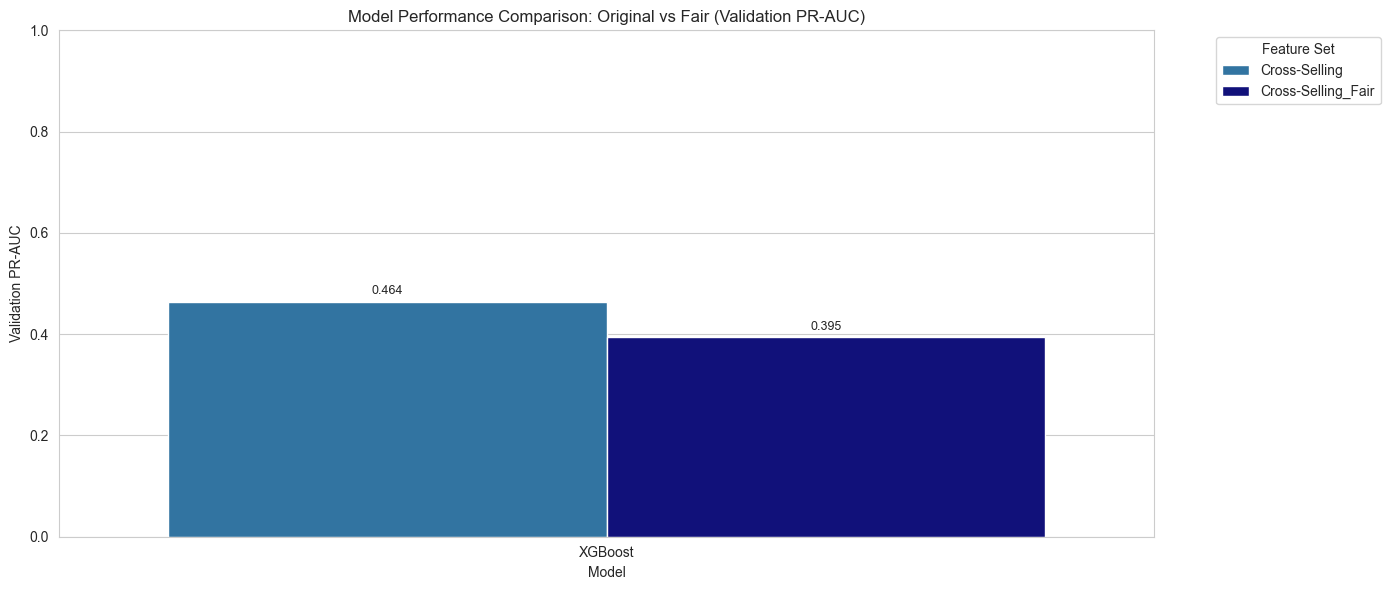

--- Cross-Selling (Best Model: XGBoost) ---
  Max Profit: $1,992.09
  At 1,383 contacts (40.8% of population)

--- Cross-Selling_Fair (Best Model: XGBoost) ---
  Max Profit: $1,968.34
  At 1,521 contacts (44.8% of population)



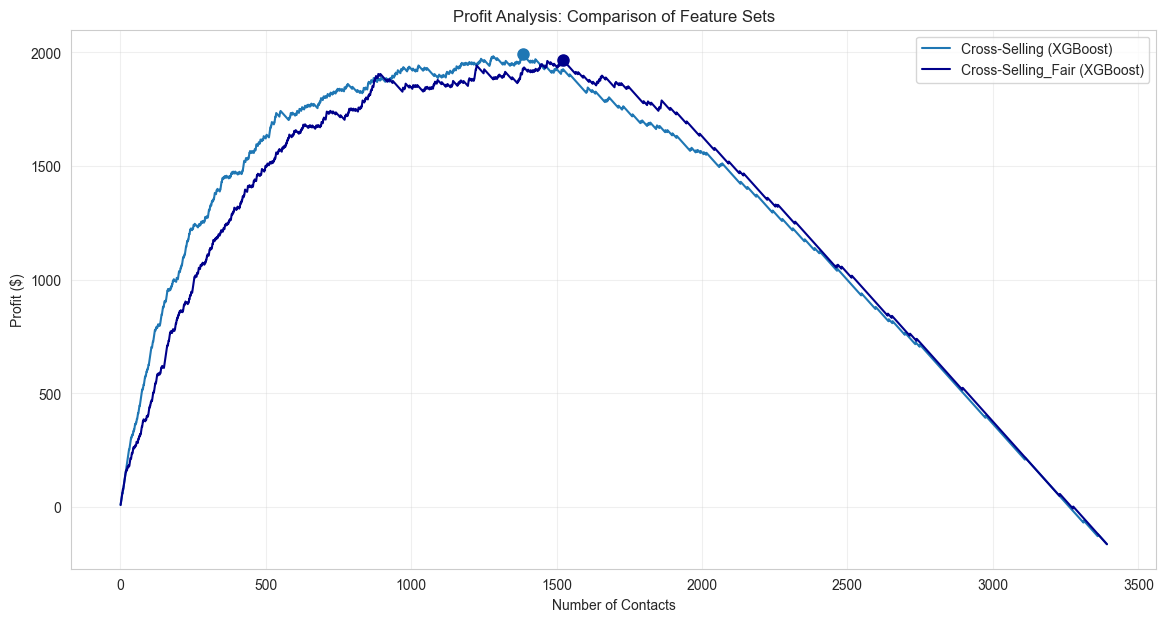

In [65]:
# --- 1. Bar Chart: Validation PR-AUC (All Models) ---
# Filter relevant results
relevant_feature_sets_v1 = ['Cross-Selling']
results_v1_filtered = [r for r in all_results if r['Feature_Set'] in relevant_feature_sets_v1]

relevant_feature_sets_fair = ['Cross-Selling_Fair']
results_fair_filtered = [r for r in results_fair if r['Feature_Set'] in relevant_feature_sets_fair]
combined_results = results_v1_filtered + results_fair_filtered
combined_results_df = pd.DataFrame(combined_results)
  
# Define Model Order
model_order = ['XGBoost']
# Filter model order to only include models present in the data
model_order = [m for m in model_order if m in combined_results_df['Model'].unique()]

# Define Feature Set Order explicitly for the plot
feature_set_order = relevant_feature_sets_v1 + relevant_feature_sets_fair

# Define Colors
custom_colors = {
    'Cross-Selling': '#1f77b4',
    'Cross-Selling_Fair': '#00008B'
}

plt.figure(figsize=(14, 6))
ax = sns.barplot(
    data=combined_results_df,
    x="Model",
    y="Val_PR_AUC",
    hue="Feature_Set",
    hue_order=feature_set_order,
    order=model_order,
    palette=custom_colors
)

# Labels
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=3, fontsize=9)
    
plt.title("Model Performance Comparison: Original vs Fair (Validation PR-AUC)")
plt.ylim(0, 1.0)
plt.ylabel("Validation PR-AUC")
plt.xlabel("Model")
plt.legend(title="Feature Set", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

# --- 2. Profit Analysis (Best Model per Feature Set) ---

# Identify best model for each feature set
best_models_combined = {}

# From V1
for fs in relevant_feature_sets_v1:
    if 'best_models' in locals() and fs in best_models_set:
         best_models_combined[fs] = best_models_set[fs]
    else:
        fs_results = [r for r in all_results if r['Feature_Set'] == fs]
        if fs_results:
            best_entry = max(fs_results, key=lambda x: x['Val_PR_AUC'])
            best_models_combined[fs] = best_entry

# From V2
for fs in relevant_feature_sets_fair:
    fs_results = [r for r in results_fair if r['Feature_Set'] == fs]
    if fs_results:
        best_entry = max(fs_results, key=lambda x: x['Val_PR_AUC'])
        best_models_combined[fs] = best_entry
plt.figure(figsize=(14, 7))

# Map internal feature names to display names and colors
fs_display_info = {
    'Cross-Selling': {'label': 'Cross-Selling', 'color': '#1f77b4'},
    'Cross-Selling_Fair': {'label': 'Cross-Selling_Fair', 'color': '#00008B'}
}

for fs_name, entry in best_models_combined.items():
    model = entry['Model_Instance']
    model_name = entry['Model']
    
    display_info = fs_display_info.get(fs_name, {'label': fs_name, 'color': 'gray'})
    label_name = display_info['label']
    color = display_info['color']
    
    print(f"--- {label_name} (Best Model: {model_name}) ---")
    
    # Check where the feature set is located
    if fs_name in data_splits:
        X_test_curr = data_splits[fs_name]['X_test']
        y_test_curr = data_splits[fs_name]['y_test']
    elif 'data_splits_fair' in locals() and fs_name in data_splits_fair:
        X_test_curr = data_splits_fair[fs_name]['X_test']
        y_test_curr = data_splits_fair[fs_name]['y_test']
    else:
        print(f"  Warning: Data split for {fs_name} not found. Skipping.")
        continue

    # Get probabilities (handle models without predict_proba)
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test_curr)[:, 1]
    else:
        y_prob = model.predict(X_test_curr)

    y_true = np.array(y_test_curr)
    n = len(y_true)
    
    # Apply fixed cost only for Realistic feature sets
    if 'Realistic' in fs_name:
        fix_cost = cost_per_record * n
    else:
        fix_cost = 0
        
    # Calculate Profit Curve using the helper function
    x_pct, profit = calculate_profit_curve(
        y_true, 
        y_prob, 
        cost_per_contact, 
        fix_cost, 
        expected_benefit_per_right_person
    )
    
    # Convert x-axis back to number of contacts for plotting
    cum_contacted = x_pct * n
    
    # Plot Profit Curve
    plt.plot(cum_contacted, profit, label=f"{label_name} ({model_name})", color=color)
    
    # Max Profit
    max_profit_idx = np.argmax(profit)
    max_profit_val = profit[max_profit_idx]
    
    # Mark max profit point
    plt.plot(cum_contacted[max_profit_idx], max_profit_val, 'o', 
             color=color, markersize=8)
    
    print(f"  Max Profit: ${max_profit_val:,.2f}")
    print(f"  At {cum_contacted[max_profit_idx]:,.0f} contacts ({x_pct[max_profit_idx]:.1%} of population)")
    print()

plt.title('Profit Analysis: Comparison of Feature Sets')
plt.xlabel('Number of Contacts')
plt.ylabel('Profit ($)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

---